<a href="https://colab.research.google.com/github/mohiddinyallur/3ev-Vehicles-breakdown-analysis/blob/main/3ev_weekly_breakdown_report_vs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 3ev weekly breakdowns report

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Import libraries and data

In [ ]:
import numpy as n
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


In [ ]:
data=pd.read_csv('/content/drive/MyDrive/3ev-Data analytics /Weekly breakdowns report/Oct_1_2024-Nov_9_2025 breakdowns.csv')

In [ ]:
data.head(10)

,ID,vin,RTO Registration Number,Vehicle Model,FOS,FON,Incident Date,Incident Time,Incident Type,Status,Responsiblity,Root cause,Date of Closure,Time of Closure
0,IR202511097,MD9B30CWWND558386,KA53AA6124,S8Ci,Hastinapuram,HYD,"November 9, 2025",22.03,Accident,CREATED,3eco,Accidental damages,NaN,NaN
1,IR202511096,MD9B30CWWMJ558197,KA53AA4723,S8Ci,Hastinapuram,HYD,"November 9, 2025",21.56,Mechanical,CREATED,3evi,Datai gearbox issue,NaN,NaN
2,IR202511094,MD9B55CWWPD558845,KA53AB1340,S8Ci,Hastinapuram,HYD,"November 9, 2025",21.55,Mechanical,CREATED,3evi,Datai gearbox issue,NaN,NaN
3,IR202511093,MD9B30CWWND558447,MH04KX8317,S8Ci,Dombivli,MMB,"November 9, 2025",10.30,Mechanical,RESOLVED,3evi,Front fork issue,"November 11, 2025",20.54
4,IR202511092,MD9B30CWWPH559078,KA53AB3893,S8Ci,Dombivli,MMB,"November 9, 2025",10.30,Mechanical,RESOLVED,3evi,Front fork issue,"November 11, 2025",21.00
5,IR202511091,MD9B55CWWPD558826,MH04KX8311,S8Ci,Dombivli,MMB,"November 9, 2025",10.30,Mechanical,RESOLVED,3evi,Brake issue,"November 10, 2025",21.54
6,IR2025110813,MD9B55CWWPJ559115,KA53AB7642,S8Ci,Bhiwandi,MMB,"November 8, 2025",12.59,Electrical,CREATED,3evi,SEG motor issue,NaN,NaN
7,IR2025110812,MD9B55CWWPE558943,KA53AB1380,S8Ci,Goregaon,MMB,"November 8, 2025",13.32,Mechanical,RESOLVED,3evi,Brake issue,"November 9, 2025",21.12
8,IR2025110811,MD9B30CWWNE558503,MH04KX8309,Rhino,Dombivli,MMB,"November 8, 2025",11.52,Electrical,RESOLVED,3evi,DC-DC convertor issue,"November 11, 2025",21.24
9,IR2025110810,MD9B55CWWPD558775,MH04KX7321,S8Ci,Dombivli,MMB,"November 8, 2025",11.11,Mechanical,RESOLVED,3evi,Gear cable issue,"November 9, 2025",21.27


## Data wrangling and cleaning

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3680 entries, 0 to 3679
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID                       3680 non-null   object 
 1   vin                      3680 non-null   object 
 2   RTO Registration Number  3680 non-null   object 
 3   Vehicle Model            3680 non-null   object 
 4   FOS                      3680 non-null   object 
 5   FON                      3680 non-null   object 
 6   Incident Date            3680 non-null   object 
 7   Incident Time            3680 non-null   float64
 8   Incident Type            3680 non-null   object 
 9   Status                   3680 non-null   object 
 10  Responsiblity            3635 non-null   object 
 11  Root cause               3680 non-null   object 
 12  Date of Closure          3550 non-null   object 
 13  Time of Closure          3550 non-null   float64
dtypes: float64(2), object(12

In [ ]:
data.describe()

,Incident Time,Time of Closure
count,3680.000000,3550.000000
mean,11.694329,18.142231
std,3.547267,6.255054
min,0.000000,0.000000
25%,9.370000,16.512500
50%,11.290000,20.385000
75%,13.430000,22.370000
max,23.590000,23.590000


In [ ]:
# Convert 'Incident Date' and 'Date of Closure' to datetime objects
data['Incident Date'] = pd.to_datetime(data['Incident Date'])
data['Date of Closure'] = pd.to_datetime(data['Date of Closure'])



In [ ]:
max(data['Incident Date'])


Timestamp('2025-11-09 00:00:00')

In [ ]:
min(data['Incident Date'])

Timestamp('2024-10-01 00:00:00')

In [ ]:
 #remove rows which are before Aug 1 2024, The analysis is for a year.

from datetime import datetime
# Filter out rows before Aug 1, 2024
data = data[data['Incident Date'] >= datetime(2024, 8, 1)]

In [ ]:
min(data['Incident Date'])

Timestamp('2024-10-01 00:00:00')

In [ ]:
# Count the rows where 'Status' is 'REJECTED'
#These rows have been cleaned in pre-processing -csv is cleaned
rejected_count = data[data['Status'] == 'REJECTED'].shape[0]

# Print the count of rejected rows
print(rejected_count)

0


In [ ]:
# count incidents and group them by Incident Type

incident_counts = data.groupby('Incident Type')['Incident Type'].count()
print(incident_counts)


Incident Type
Accident       455
Electrical    1118
Mechanical    2107
Name: Incident Type, dtype: int64


In [ ]:
#  group count of ID by status, just print the Status and count of ids for that status

id_count_by_status = data.groupby('Status')['ID'].count()
print(id_count_by_status)


Status
CREATED       114
ESTIMATED      16
RESOLVED     3550
Name: ID, dtype: int64


## KPI -Data analysis

### Last 7 days analysis

In [ ]:
#Table for breakdowns from 7 days before the last date in the dataset
from datetime import datetime, timedelta

start_date = datetime(2025, 11, 3)
end_date = datetime(2025, 11, 9)
last_7_days_data = data[(data['Incident Date'] >= start_date) & (data['Incident Date'] <= end_date)]

# 1. Table: with accident
fon_breakdown_all = last_7_days_data.groupby(['FON', 'Incident Type'])['ID'].count().unstack().fillna(0)
fon_breakdown_all['Total'] = fon_breakdown_all.sum(axis=1)
print("FON Wise Breakdowns (All Incident Types) from 3rd Nov to 9th Nov 2025")
display(fon_breakdown_all)


# 2. Table: Without Accident
no_accident_data = last_7_days_data[last_7_days_data['Incident Type'] != 'Accident']
fon_breakdown_no_accident = no_accident_data.groupby(['FON', 'Incident Type'])['ID'].count().unstack().fillna(0)
fon_breakdown_no_accident['Total'] = fon_breakdown_no_accident.sum(axis=1)
print("FON Wise Breakdowns (Without Accidents)from 3rd Nov to 9th Nov 2025")
display(fon_breakdown_no_accident)

FON Wise Breakdowns (All Incident Types) from 3rd Nov to 9th Nov 2025


Incident Type,Accident,Electrical,Mechanical,Total
FON,,,,
BLR,1,1,8,10
CHN,4,6,24,34
HYD,2,1,8,11
MMB,4,24,28,56


FON Wise Breakdowns (Without Accidents)from 3rd Nov to 9th Nov 2025


Incident Type,Electrical,Mechanical,Total
FON,,,
BLR,1,8,9
CHN,6,24,30
HYD,1,8,9
MMB,24,28,52


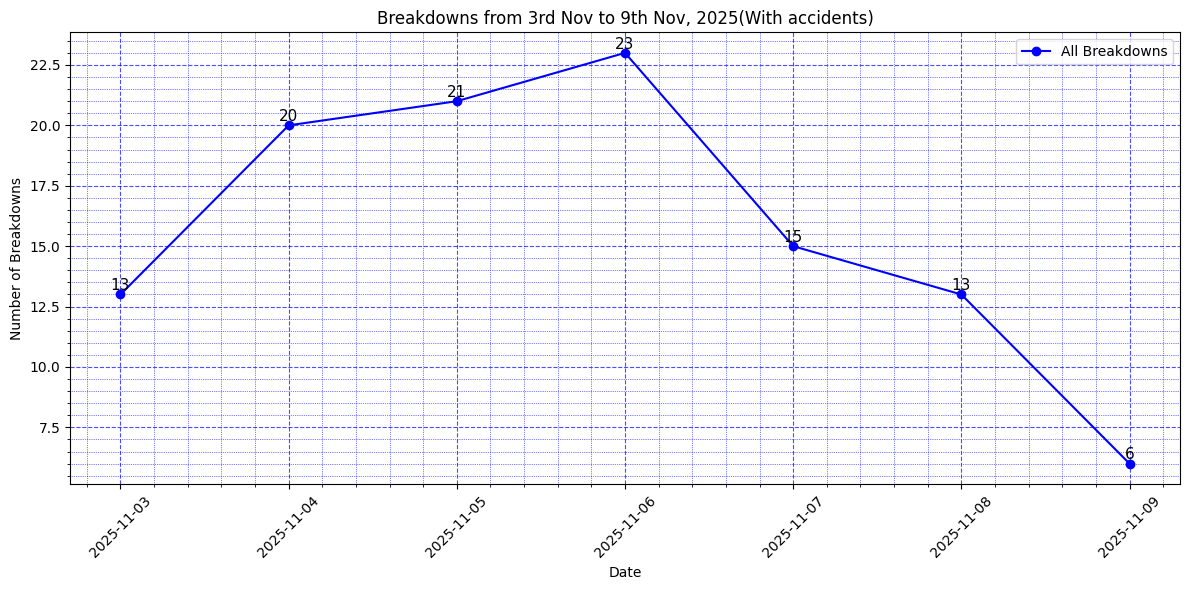

In [ ]:
#Table for breakdowns from 7 days before the last date in the dataset
from datetime import datetime, timedelta

start_date = datetime(2025, 11, 3)
end_date = datetime(2025, 11, 9)
period_data = data[(data['Incident Date'] >= start_date) & (data['Incident Date'] <= end_date)]

# Graph 1: All Breakdown Types for the period
daily_breakdowns_all = period_data.groupby('Incident Date')['ID'].count()

# Reindex to include all dates in the range, filling missing dates with zero
all_dates = pd.date_range(start=start_date, end=end_date)
daily_breakdowns_all = daily_breakdowns_all.reindex(all_dates, fill_value=0)

plt.figure(figsize=(12, 6))
plt.plot(daily_breakdowns_all.index, daily_breakdowns_all.values, marker='o', linestyle='-', color='blue', label='All Breakdowns')

# Add data labels to the points
for x, y in zip(daily_breakdowns_all.index, daily_breakdowns_all.values):
    plt.text(x, y+0.05, str(y), ha='center', va='bottom', fontsize=11)
# Customization
plt.xlabel('Date')
plt.ylabel('Number of Breakdowns')
plt.title('Breakdowns from 3rd Nov to 9th Nov, 2025(With accidents)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
# Major gridlines (dashed blue)
plt.grid(True, linestyle='--', alpha=0.7, color='blue')

# Minor gridlines (finer, lighter blue)
plt.minorticks_on()
plt.grid(which='minor', linestyle=':', linewidth=0.5, color='blue')
plt.show()

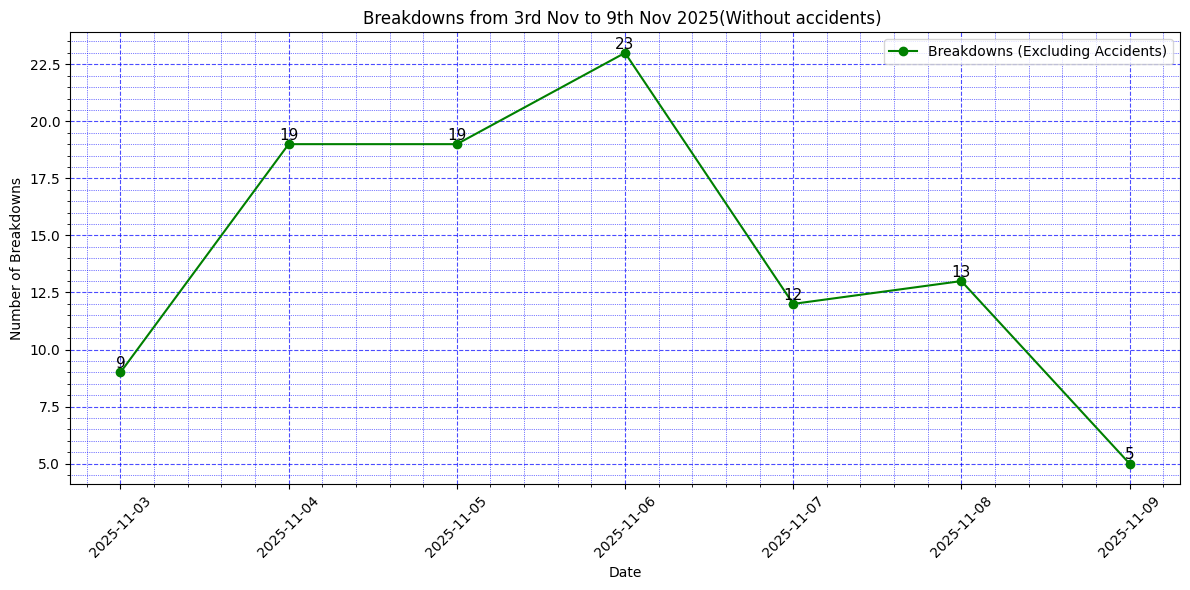

In [ ]:
# Graph 2: Breakdowns excluding accidents for the period
no_accidents_data = period_data[period_data['Incident Type'] != 'Accident']
daily_breakdowns_no_accidents = no_accidents_data.groupby('Incident Date')['ID'].count()

# Reindex to include all dates in the range, filling missing dates with zero
all_dates = pd.date_range(start=start_date, end=end_date)
daily_breakdowns_no_accidents = daily_breakdowns_no_accidents.reindex(all_dates, fill_value=0)


plt.figure(figsize=(12, 6))

plt.plot(daily_breakdowns_no_accidents.index, daily_breakdowns_no_accidents.values, marker='o', linestyle='-', color='green', label='Breakdowns (Excluding Accidents)')

# Add data labels to the points
for x, y in zip(daily_breakdowns_no_accidents.index, daily_breakdowns_no_accidents.values):
    plt.text(x, y+0.05, str(y), ha='center', va='bottom', fontsize=11)

# Customization
plt.xlabel('Date')
plt.ylabel('Number of Breakdowns')
plt.title('Breakdowns from 3rd Nov to 9th Nov 2025(Without accidents) ')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
# Major gridlines (dashed blue)
plt.grid(True, linestyle='--', alpha=0.7, color='blue')

# Minor gridlines (finer, lighter blue)
plt.minorticks_on()
plt.grid(which='minor', linestyle=':', linewidth=0.5, color='blue')
plt.show()

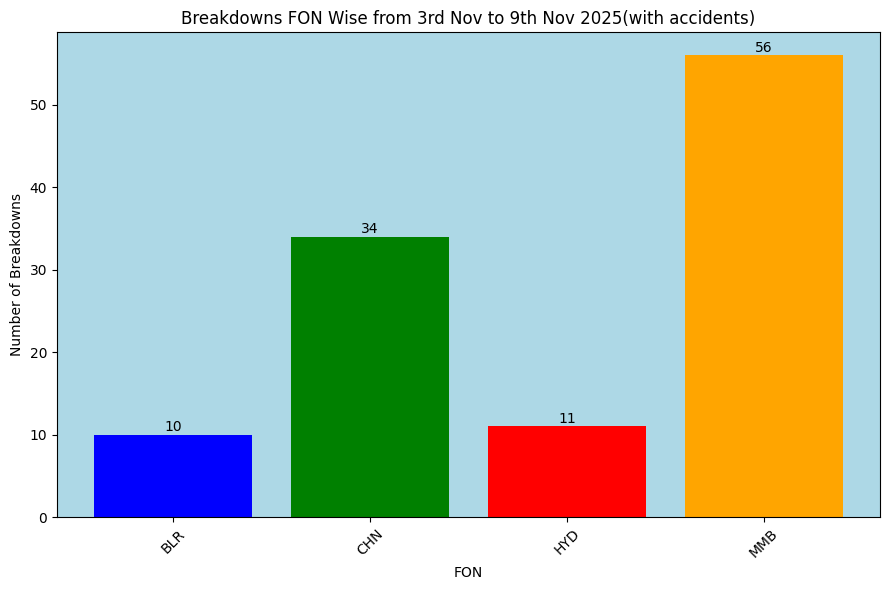

In [ ]:
# last 7 days breakdowns FON wise

# Group by FON and count breakdowns
fon_breakdowns = last_7_days_data.groupby('FON')['ID'].count()

# Create a bar chart with different colors for each bar
plt.figure(figsize=(9, 6))
bars = plt.bar(fon_breakdowns.index, fon_breakdowns.values, color=['blue', 'green', 'red', 'orange', 'purple'])
plt.xlabel('FON')
plt.ylabel('Number of Breakdowns')
plt.title('Breakdowns FON Wise from 3rd Nov to 9th Nov 2025(with accidents)')


# Add data labels on top of each bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.1, yval, ha='center', va='bottom')
# Set the light blue background
plt.gca().set_facecolor('lightblue')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

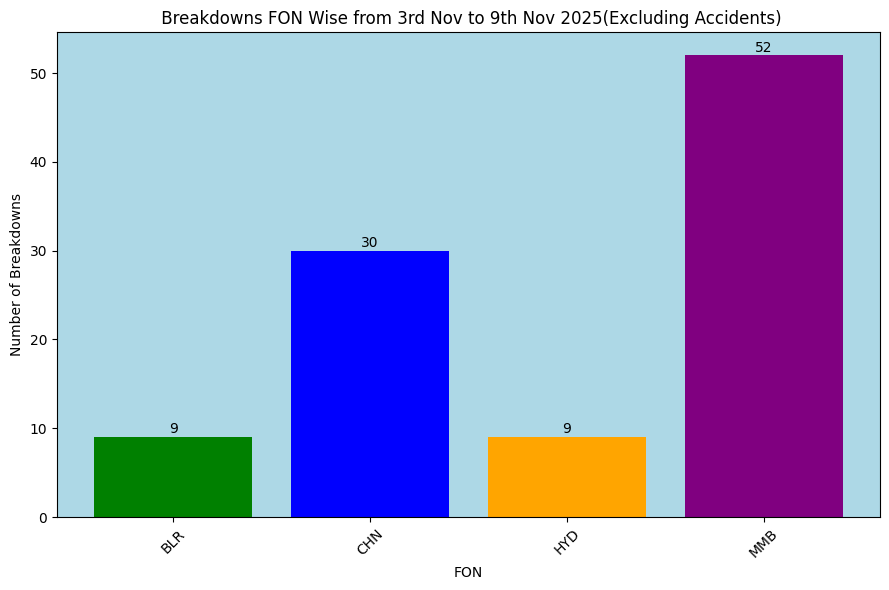

In [ ]:
#  without accidents

import matplotlib.pyplot as plt
# Filter out rows with 'Incident Type' as 'Accident'
no_accidents_data_last_7_days = last_7_days_data[last_7_days_data['Incident Type'] != 'Accident']

# Group by FON and count breakdowns (excluding accidents)
fon_breakdowns_no_accidents = no_accidents_data_last_7_days.groupby('FON')['ID'].count()

# Create a bar chart with different colors for each bar
plt.figure(figsize=(9, 6))
bars = plt.bar(fon_breakdowns_no_accidents.index, fon_breakdowns_no_accidents.values, color=['green','blue', 'orange','purple', 'brown'])
plt.xlabel('FON')
plt.ylabel('Number of Breakdowns')
plt.title(' Breakdowns FON Wise from 3rd Nov to 9th Nov 2025(Excluding Accidents)')


# Add data labels on top of each bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.1, yval, ha='center', va='bottom')
# Set the light blue background
plt.gca().set_facecolor('lightblue')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

last 7 days breakdowns by type

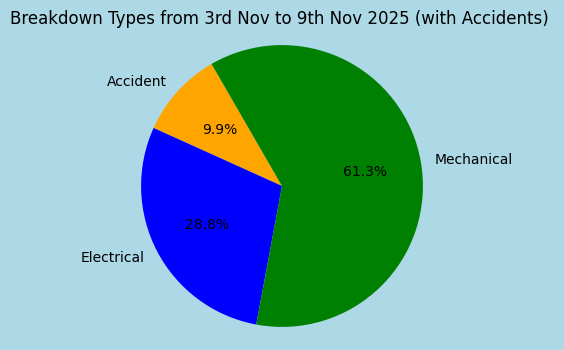

Incident Type Counts:
Incident Type
Accident      11
Electrical    32
Mechanical    68
Name: ID, dtype: int64


In [ ]:
#Table for breakdowns from 7 days before the last date in the dataset
from datetime import datetime, timedelta

start_date = datetime(2025, 11, 3)
end_date = datetime(2025, 11, 9)
period_data = data[(data['Incident Date'] >= start_date) & (data['Incident Date'] <= end_date)]

# Group by Incident Type and count the number of breakdowns
incident_type_counts = period_data.groupby('Incident Type')['ID'].count()

# Create a pie chart
plt.figure(figsize=(4, 4))
colors = ['orange', 'blue','green']  # Define colors for each slice
plt.pie(incident_type_counts, labels=incident_type_counts.index, autopct='%1.1f%%', startangle=120, colors=colors)
plt.title('Breakdown Types from 3rd Nov to 9th Nov 2025 (with Accidents) ')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.

plt.gcf().set_facecolor('lightblue')

# Add a border around the plot
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_edgecolor('black')  # Border color
    spine.set_linewidth(2)        # Border thickness

plt.show()


# Print the counts for each incident type
print("Incident Type Counts:")
print(incident_type_counts)

Root cause analysis -last 7 days

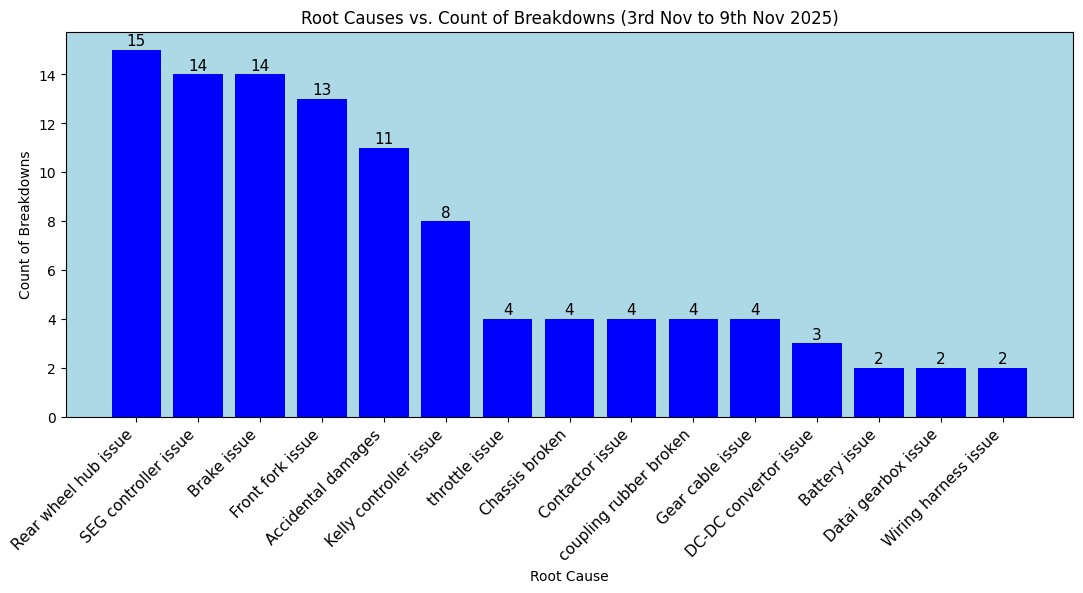

In [ ]:

# Group by 'Root Cause' and count breakdowns
root_cause_counts = period_data.groupby('Root cause')['ID'].count().sort_values(ascending=False).head(15)

# Create a bar chart
plt.figure(figsize=(13, 5))
bars = plt.bar(root_cause_counts.index, root_cause_counts.values, color='Blue')
plt.xlabel('Root Cause')
plt.ylabel('Count of Breakdowns')
plt.title('Root Causes vs. Count of Breakdowns (3rd Nov to 9th Nov 2025)')
plt.xticks(rotation=45, ha='right', fontsize=11, color='black')  # Rotate x-axis labels for better readability

# Add data labels on top of each bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.05, yval, ha='center', va='bottom',color='black',size=11)

plt.gca().set_facecolor('lightblue')


plt.show()

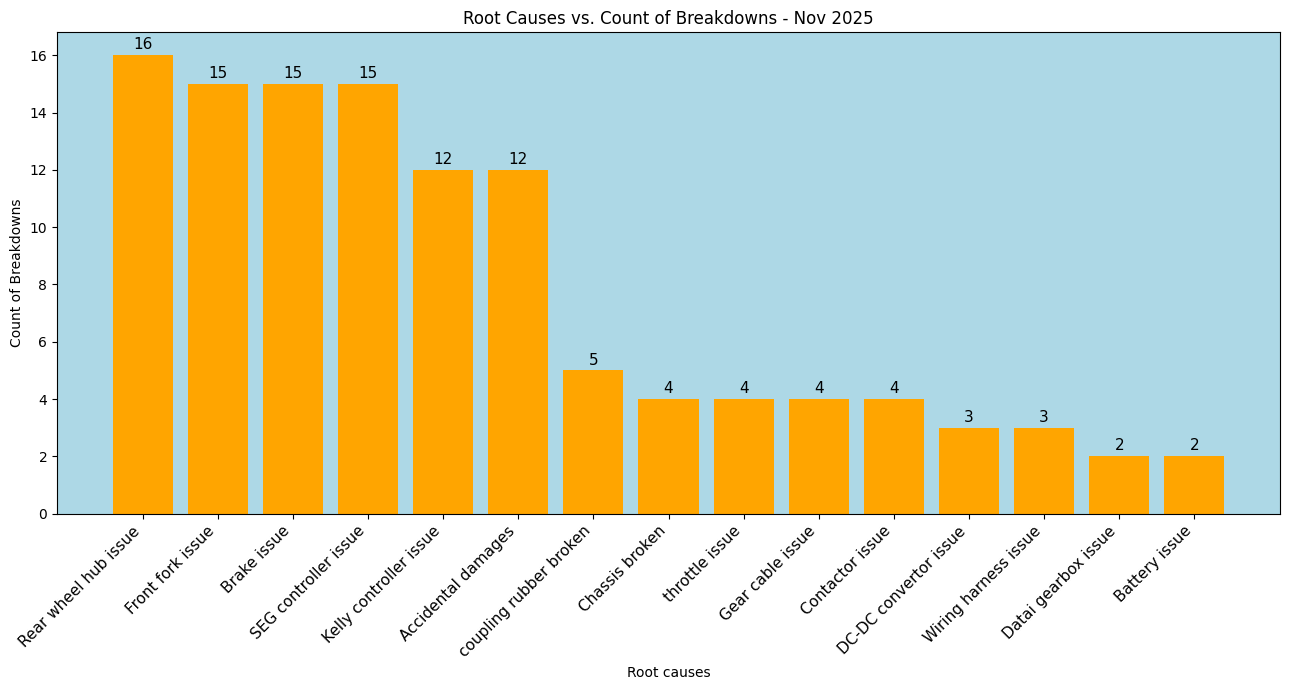

In [ ]:
#Table for breakdowns from  1 Nov to 30 Nov 2025- MTD root cause
from datetime import datetime, timedelta

start_date = datetime(2025, 11, 1)
end_date = datetime(2025, 11, 30)
MTD_data = data[(data['Incident Date'] >= start_date) & (data['Incident Date'] <= end_date)]

import matplotlib.pyplot as plt
# Assuming 'period_data' DataFrame from the previous code is available

# Group by 'Root Cause' and count breakdowns
root_cause_counts = MTD_data.groupby('Root cause')['ID'].count().sort_values(ascending=False).head(15)

# Create a bar chart
plt.figure(figsize=(13,7))
bars = plt.bar(root_cause_counts.index, root_cause_counts.values, color='Orange')
plt.xlabel('Root causes')
plt.ylabel('Count of Breakdowns')
plt.title('Root Causes vs. Count of Breakdowns - Nov 2025')
plt.xticks(rotation=45, ha='right', fontsize=11, color='black')  # Rotate x-axis labels for better readability

# Add data labels on top of each bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.1, yval, ha='center', va='bottom',size=11, color='black')

plt.gca().set_facecolor('LightBlue')


plt.tight_layout()
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()


### Last 6 weeks trend

In [ ]:
 # Also Replace Accidental damages to Accidental Damages

data['Root cause'] = data['Root cause'].replace('Accidental damages', 'Accidental Damages')

Last 6 weeks trend with Accidents

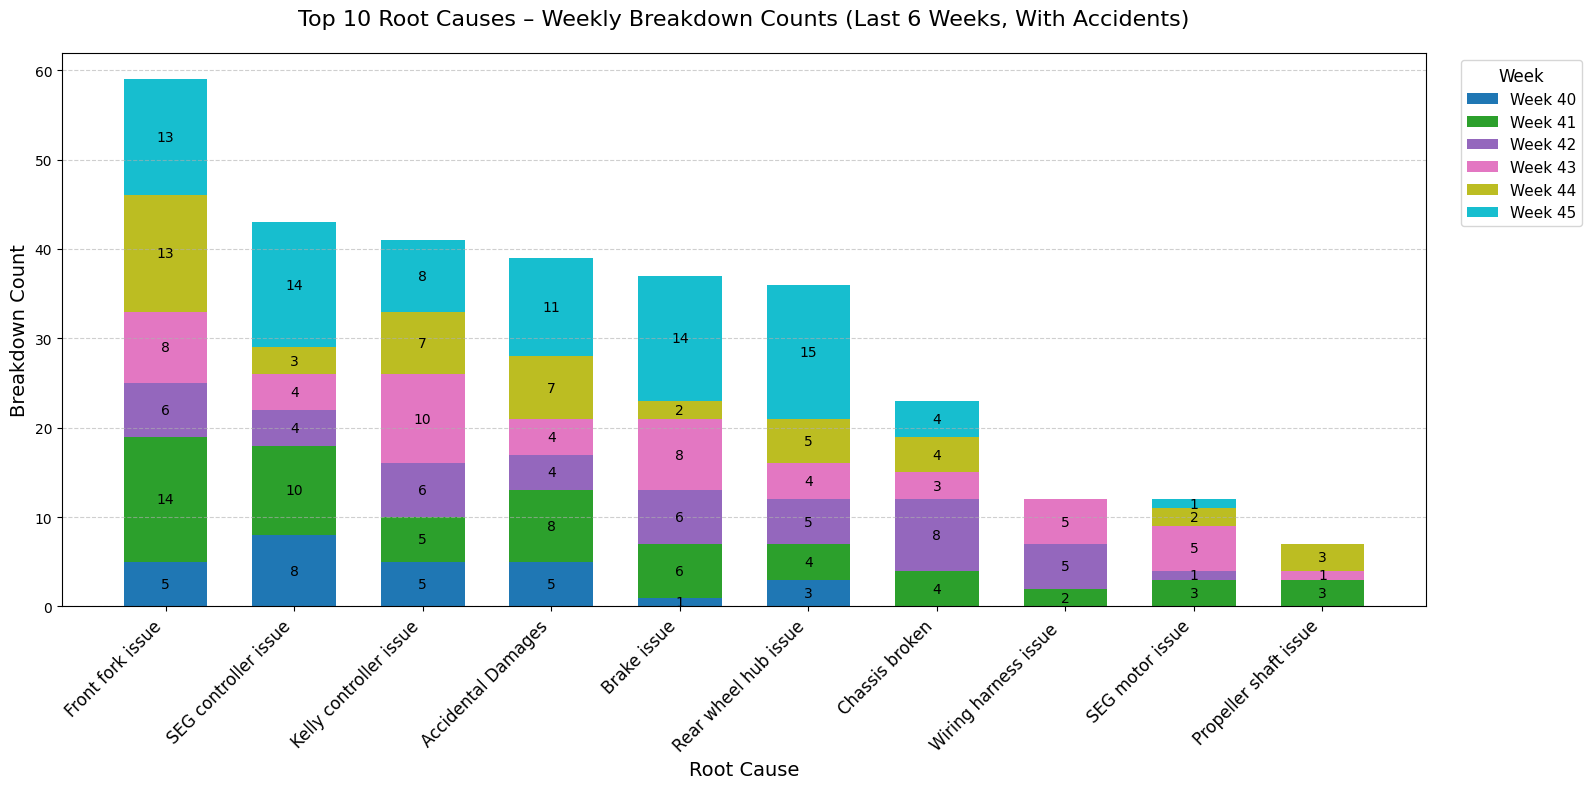

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from datetime import timedelta

# --- 1) Convert and extract ISO week fields ---
data['Incident Date'] = pd.to_datetime(data['Incident Date'])
iso = data['Incident Date'].dt.isocalendar()
data['ISO_Year'] = iso['year'].astype(int)
data['ISO_Week'] = iso['week'].astype(int)
data['Year_Week'] = data['ISO_Year'].astype(str) + '-' + data['ISO_Week'].astype(str).str.zfill(2)

# --- 2) Compute the last 6 ISO weeks (calendar-wise, not just existing data) ---
latest_date = data['Incident Date'].max()
latest_iso = latest_date.isocalendar()

iso_weeks = []
year, week = latest_iso.year, latest_iso.week
for _ in range(6):
    iso_weeks.append(f"{year}-{str(week).zfill(2)}")
    week -= 1
    if week == 0:  # wrap around to previous year
        year -= 1
        week = pd.Timestamp(f'{year}-12-28').isocalendar().week

last_6_weeks = list(reversed(iso_weeks))  # chronological order

# --- 3) Filter data to those weeks ---
filtered = data[data['Year_Week'].isin(last_6_weeks)]

# --- 4) Pivot: Root cause vs Year_Week ---
pivot = (
    filtered
    .groupby(['Root cause', 'Year_Week'])['ID']
    .count()
    .unstack(fill_value=0)
)

# Ensure all 6 weeks appear (even if no incidents)
pivot = pivot.reindex(columns=last_6_weeks, fill_value=0)

# --- 5) Top 10 root causes across last 6 weeks ---
top10_index = (
    pivot.sum(axis=1)
         .sort_values(ascending=False)
         .head(10)
         .index
)
pivot_top10 = pivot.loc[top10_index]

# --- 6) Legend labels ---
years_in_window = {yw.split('-')[0] for yw in last_6_weeks}
def week_label(yw):
    y, w = yw.split('-')
    return f"Week {int(w)}" if len(years_in_window) == 1 else f"Week {int(w)} ({y})"

legend_labels = [week_label(yw) for yw in pivot_top10.columns]

# --- 7) Plot stacked bars ---
fig, ax = plt.subplots(figsize=(16, 8))
x = np.arange(len(top10_index))
bottom = np.zeros(len(top10_index))
colors = plt.cm.tab10(np.linspace(0, 1, len(last_6_weeks)))

for idx, col in enumerate(pivot_top10.columns):
    vals = pivot_top10[col].values
    bars = ax.bar(
        x, vals, bottom=bottom, label=legend_labels[idx],
        color=colors[idx % len(colors)], width=0.65
    )
    # Add data labels
    for bar, v in zip(bars, vals):
        if v > 0:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_y() + bar.get_height() / 2,
                int(v),
                ha='center', va='center', fontsize=10, color='black'
            )
    bottom += vals

# --- 8) Formatting ---
ax.set_xticks(x)
ax.set_xticklabels(top10_index, rotation=45, ha='right', fontsize=12)
ax.set_xlabel('Root Cause', fontsize=14)
ax.set_ylabel('Breakdown Count', fontsize=14)
ax.set_title('Top 10 Root Causes – Weekly Breakdown Counts (Last 6 Weeks, With Accidents)', fontsize=16, pad=20)
ax.legend(title='Week', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=11, title_fontsize=12)
ax.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


### without accidents

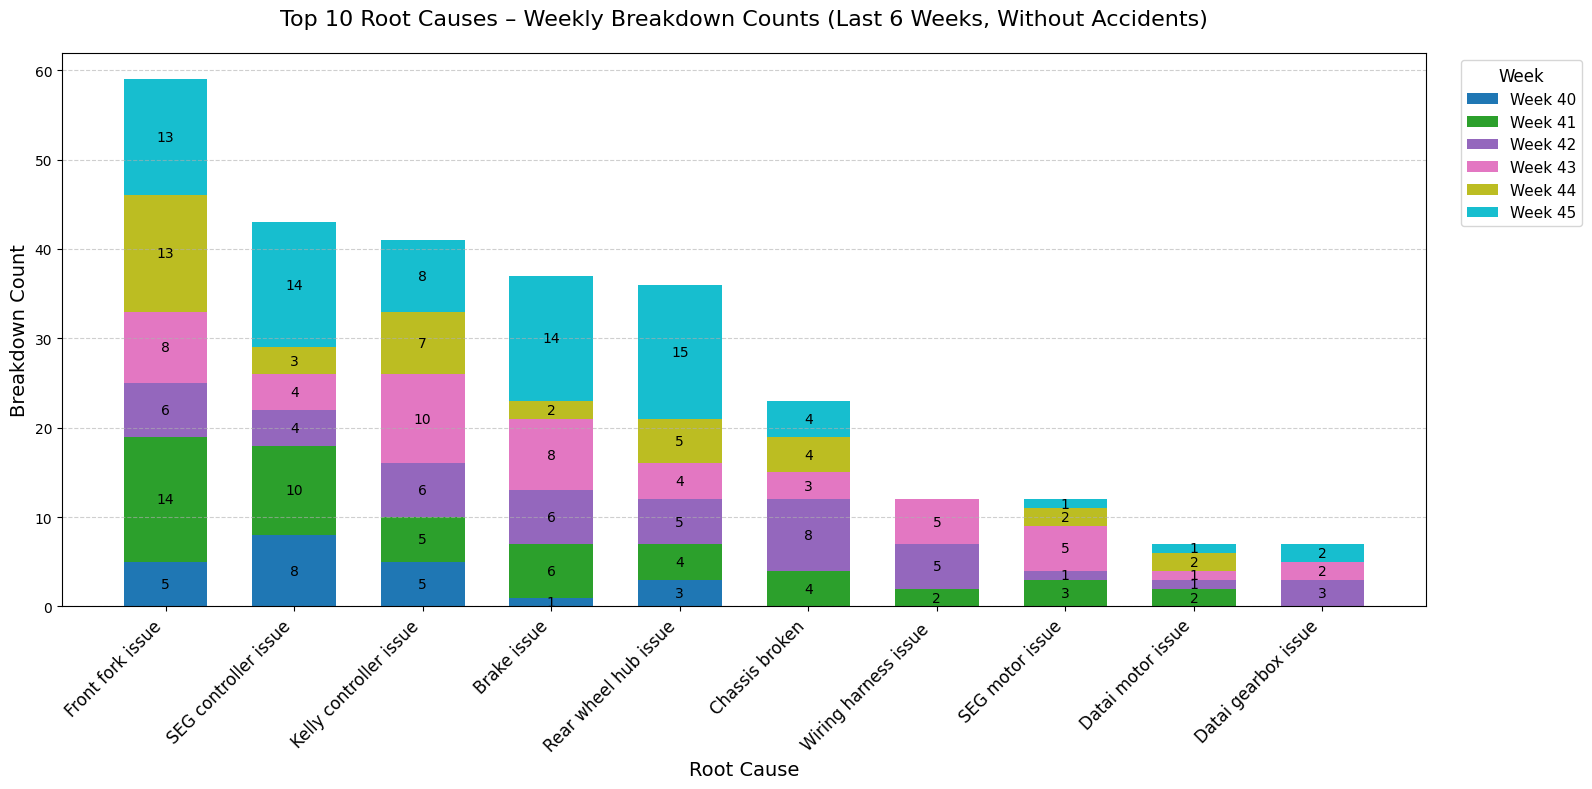

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1) Ensure datetime + ISO week extraction
data['Incident Date'] = pd.to_datetime(data['Incident Date'])
iso = data['Incident Date'].dt.isocalendar()
data['ISO_Year'] = iso['year'].astype(int)
data['ISO_Week'] = iso['week'].astype(int)
data['Year_Week'] = data['ISO_Year'].astype(str) + '-' + data['ISO_Week'].astype(str).str.zfill(2)

# 2) Filter OUT accidents using Incident Type
no_accidents_data = data[data['Incident Type'] != 'Accident']

# 3) Last 6 ISO weeks from no_accidents_data
week_index = (
    no_accidents_data[['Incident Date', 'ISO_Year', 'ISO_Week', 'Year_Week']]
    .sort_values(['ISO_Year', 'ISO_Week', 'Incident Date'])
    .drop_duplicates('Year_Week', keep='last')
)
last_6_weeks = week_index.tail(6)['Year_Week'].tolist()

# 4) Filter to those weeks
filtered = no_accidents_data[no_accidents_data['Year_Week'].isin(last_6_weeks)]

# 5) Pivot table (Root cause vs Year_Week)
pivot = (
    filtered
    .groupby(['Root cause', 'Year_Week'])['ID']
    .count()
    .unstack(fill_value=0)
)

# 6) Top 10 root causes
top10_index = (
    pivot.reindex(columns=last_6_weeks, fill_value=0)
         .sum(axis=1)
         .sort_values(ascending=False)
         .head(10)
         .index
)
pivot_top10 = pivot.loc[top10_index].reindex(columns=last_6_weeks, fill_value=0)

# 7) Legend labels (Week 28, Week 29 …)
years_in_window = {yw.split('-')[0] for yw in last_6_weeks}
def week_label(yw):
    y, w = yw.split('-')
    return f"Week {int(w)}" if len(years_in_window) == 1 else f"Week {int(w)} ({y})"
legend_labels = [week_label(yw) for yw in pivot_top10.columns]

# 8) Plot stacked bars
fig, ax = plt.subplots(figsize=(16, 8))
x = np.arange(len(top10_index))
bottom = np.zeros(len(top10_index))
colors = plt.cm.tab10(np.linspace(0, 1, len(last_6_weeks)))

for idx, col in enumerate(pivot_top10.columns):
    vals = pivot_top10[col].values
    bars = ax.bar(x, vals, bottom=bottom, label=legend_labels[idx], color=colors[idx], width=0.65)
    # black labels inside segments
    for bar, v in zip(bars, vals):
        if v > 0:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_y() + bar.get_height() / 2,
                int(v),
                ha='center', va='center', fontsize=10, color='black'
            )
    bottom += vals

# 9) Formatting
ax.set_xticks(x)
ax.set_xticklabels(top10_index, rotation=45, ha='right', fontsize=12)
ax.set_xlabel('Root Cause', fontsize=14)
ax.set_ylabel('Breakdown Count', fontsize=14)
ax.set_title('Top 10 Root Causes – Weekly Breakdown Counts (Last 6 Weeks, Without Accidents)', fontsize=16, pad=20)
ax.legend(title='Week', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=11, title_fontsize=12)
ax.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


## Repeated breakdowns analysis

Raw incident rows in Sept: 293
Unique VINs in Sept (nunique): 246
Total_VINS computed: 246
Repeated_VINS computed: 41
      Month  Total_VINS  Repeated_VINS  Repeated_VIN_Percentage Month_Str
0   2024-12         210             25                11.904762  Dec-2024
1   2025-01         168              9                 5.357143  Jan-2025
2   2025-02         234             36                15.384615  Feb-2025
3   2025-03         195             24                12.307692  Mar-2025
4   2025-04         254             25                 9.842520  Apr-2025
5   2025-05         218             28                12.844037  May-2025
6   2025-06         246             34                13.821138  Jun-2025
7   2025-07         292             32                10.958904  Jul-2025
8   2025-08         230             27                11.739130  Aug-2025
9   2025-09         246             41                16.666667  Sep-2025
10  2025-10         236             28                11.864407  Oct

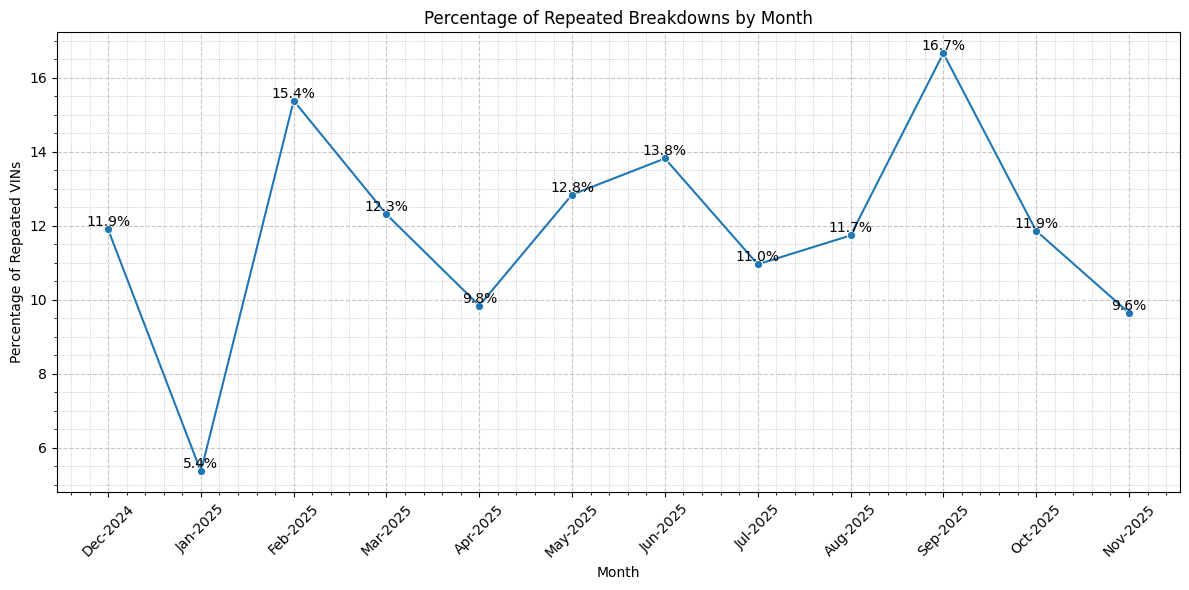

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure 'Incident Date' is in datetime format
data['Incident Date'] = pd.to_datetime(data['Incident Date'])

# Filter data as per date
start_date = '2024-12-01'
end_date = '2025-11-09'
filtered_data = data[(data['Incident Date'] >= start_date) & (data['Incident Date'] <= end_date)].copy()

# Create a Month column as Period
filtered_data['Month'] = filtered_data['Incident Date'].dt.to_period('M')

# Create a table with one row per (Month, vin) and count incidents for that vin-in-month
monthly_vin_counts = (
    filtered_data
    .groupby(['Month', 'vin'])
    .size()
    .reset_index(name='VIN_Count')  # VIN_Count = number of incidents for that VIN in that month
)

# TOTAL unique VINs per month (one row per VIN-month)
monthly_total_vins = monthly_vin_counts.groupby('Month').size().reset_index(name='Total_VINS')

# REPEATED VINs: number of VINs that had >1 incident in the same month
monthly_repeated_vins = (
    monthly_vin_counts[monthly_vin_counts['VIN_Count'] > 1]
    .groupby('Month')
    .size()
    .reset_index(name='Repeated_VINS')
)

# Merge total and repeated VINs
merged_monthly_data = pd.merge(monthly_total_vins, monthly_repeated_vins, on='Month', how='left')

# Ensure all months in the range are present (don't overwrite existing values)
full_months = pd.period_range('2024-12', '2025-11', freq='M')
full_df = pd.DataFrame({'Month': full_months})
merged_monthly_data = full_df.merge(merged_monthly_data, on='Month', how='left')

# Fill missing counts with 0 (only for months with no data)
merged_monthly_data['Total_VINS'] = merged_monthly_data['Total_VINS'].fillna(0).astype(int)
merged_monthly_data['Repeated_VINS'] = merged_monthly_data['Repeated_VINS'].fillna(0).astype(int)

# Compute percentage safely
merged_monthly_data['Repeated_VIN_Percentage'] = merged_monthly_data.apply(
    lambda row: (row['Repeated_VINS'] / row['Total_VINS'] * 100) if row['Total_VINS'] > 0 else 0,
    axis=1
)

# Convert Period to string for plotting labels
merged_monthly_data['Month_Str'] = merged_monthly_data['Month'].dt.strftime('%b-%Y')

# Enforce month order
month_order = ['Dec-2024', 'Jan-2025', 'Feb-2025', 'Mar-2025',
               'Apr-2025', 'May-2025', 'Jun-2025', 'Jul-2025',
               'Aug-2025', 'Sep-2025', 'Oct-2025','Nov-2025']
merged_monthly_data['Month_Str'] = pd.Categorical(merged_monthly_data['Month_Str'],
                                                  categories=month_order, ordered=True)
merged_monthly_data = merged_monthly_data.sort_values('Month_Str').reset_index(drop=True)

# Quick debug for September
sept = pd.Period('2025-09')
print("Raw incident rows in Sept:", filtered_data[filtered_data['Month'] == sept].shape[0])
print("Unique VINs in Sept (nunique):", filtered_data[filtered_data['Month'] == sept]['vin'].nunique())
print("Total_VINS computed:", merged_monthly_data.loc[merged_monthly_data['Month'] == sept, 'Total_VINS'].item())
print("Repeated_VINS computed:", merged_monthly_data.loc[merged_monthly_data['Month'] == sept, 'Repeated_VINS'].item())

print(merged_monthly_data)  # full table check

# Plotting using numeric x positions for stability
x = list(range(len(merged_monthly_data)))
y = merged_monthly_data['Repeated_VIN_Percentage'].values

plt.figure(figsize=(12, 6))
sns.lineplot(x=x, y=y, marker='o')

plt.xticks(x, merged_monthly_data['Month_Str'], rotation=45)
for xi, yi in zip(x, y):
    plt.text(xi, yi, f"{yi:.1f}%", ha='center', va='bottom', fontsize=10)

plt.xlabel('Month')
plt.ylabel('Percentage of Repeated VINs')
plt.title('Percentage of Repeated Breakdowns by Month')
plt.grid(True, linestyle='--', alpha=0.7)
plt.minorticks_on()
plt.grid(which='minor', linestyle=':', linewidth=0.5)
plt.tight_layout()
plt.show()


In [ ]:
pip install adjustText

In [ ]:
from adjustText import adjust_text

/tmp/ipython-input-1407087993.py:23: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  merged_fon_data['Repeated_VINS'].fillna(0, inplace=True)


42 [0.59127377 0.33646222]
43 [-0.22552572 -0.47683711]
55 [-0.3480208  -0.82662733]
57 [0.43085082 0.5278753 ]
60 [ 0.91191742 -0.08161047]
62 [-0.76516727 -0.66677231]
65 [ 0.25850253 -0.44542106]
67 [-0.55887465  0.49805053]


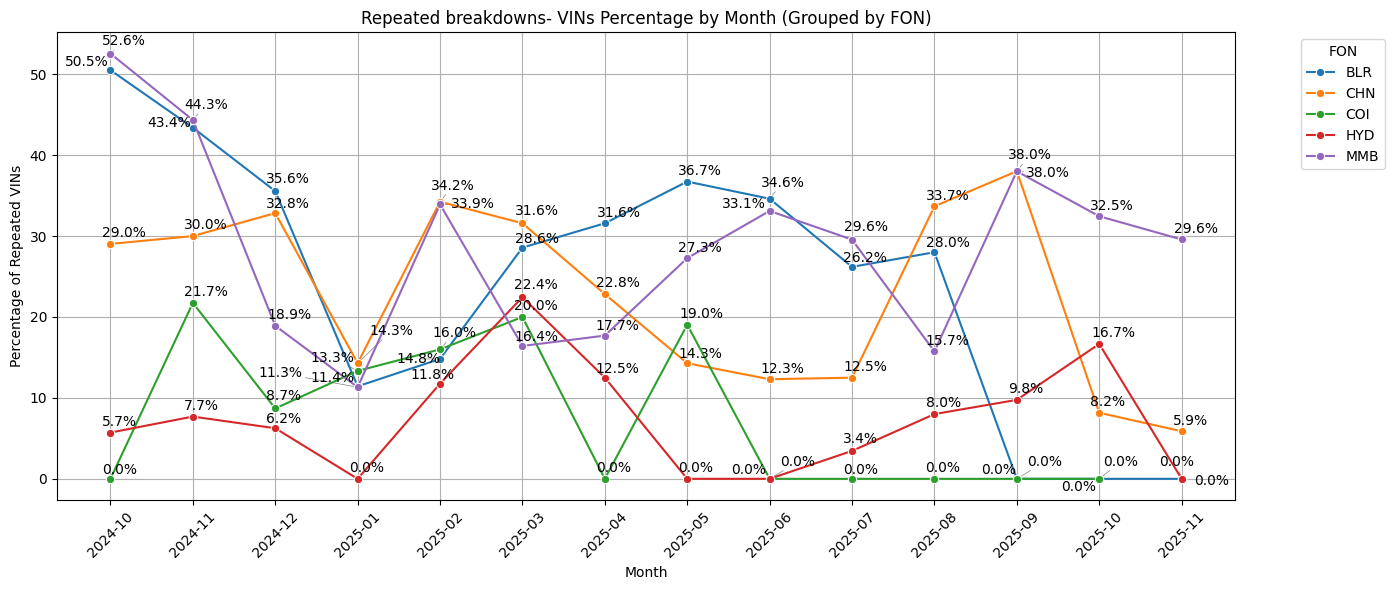

In [ ]:

# Ensure 'Incident Date' is in datetime format
data['Incident Date'] = pd.to_datetime(data['Incident Date'])

# Extract month for grouping
data['Month'] = data['Incident Date'].dt.to_period('M')

# Group by Month, FON, and VIN to count occurrences
fon_vin_counts = data.groupby(['Month', 'FON', 'vin'])['vin'].count().reset_index(name='VIN_Count')

# Calculate total VINs per FON per Month
fon_total_vins = fon_vin_counts.groupby(['Month', 'FON'])['VIN_Count'].sum().reset_index(name='Total_VINS')

# Identify repeated VINs per FON per Month
fon_repeated_vins = (
    fon_vin_counts[fon_vin_counts['VIN_Count'] > 1]
    .groupby(['Month', 'FON'])['VIN_Count']
    .sum()
    .reset_index(name='Repeated_VINS')
)

# Merge the datasets
merged_fon_data = pd.merge(fon_total_vins, fon_repeated_vins, on=['Month', 'FON'], how='left')
merged_fon_data['Repeated_VINS'].fillna(0, inplace=True)
merged_fon_data['Repeated_VIN_Percentage'] = (merged_fon_data['Repeated_VINS'] / merged_fon_data['Total_VINS']) * 100

# Convert Month to string format for better visualization
merged_fon_data['Month'] = merged_fon_data['Month'].astype(str)

# Plot: Line Graph of Repeated VINs Percentage by Month for each FON
plt.figure(figsize=(14, 6))
ax = sns.lineplot(data=merged_fon_data, x='Month', y='Repeated_VIN_Percentage', hue='FON', marker='o')

# Adding labels to each data point using adjustText
texts = []
for i, row in merged_fon_data.iterrows():
    texts.append(plt.text(row['Month'], row['Repeated_VIN_Percentage'], f"{row['Repeated_VIN_Percentage']:.1f}%",
                          ha='center', va='bottom', fontsize=10))

# Adjust text positions to prevent overlap
adjust_text(texts, arrowprops=dict(arrowstyle="-", color='gray', lw=0.5))

plt.xlabel('Month')
plt.ylabel('Percentage of Repeated VINs')
plt.title('Repeated breakdowns- VINs Percentage by Month (Grouped by FON)')
plt.xticks(rotation=45)
plt.legend(title="FON", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()




/tmp/ipython-input-53598049.py:23: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  merged_incident_type_data['Repeated_VINS'].fillna(0, inplace=True)


3 [-0.39107862  0.58915397]
31 [-0.42905134 -0.99105213]


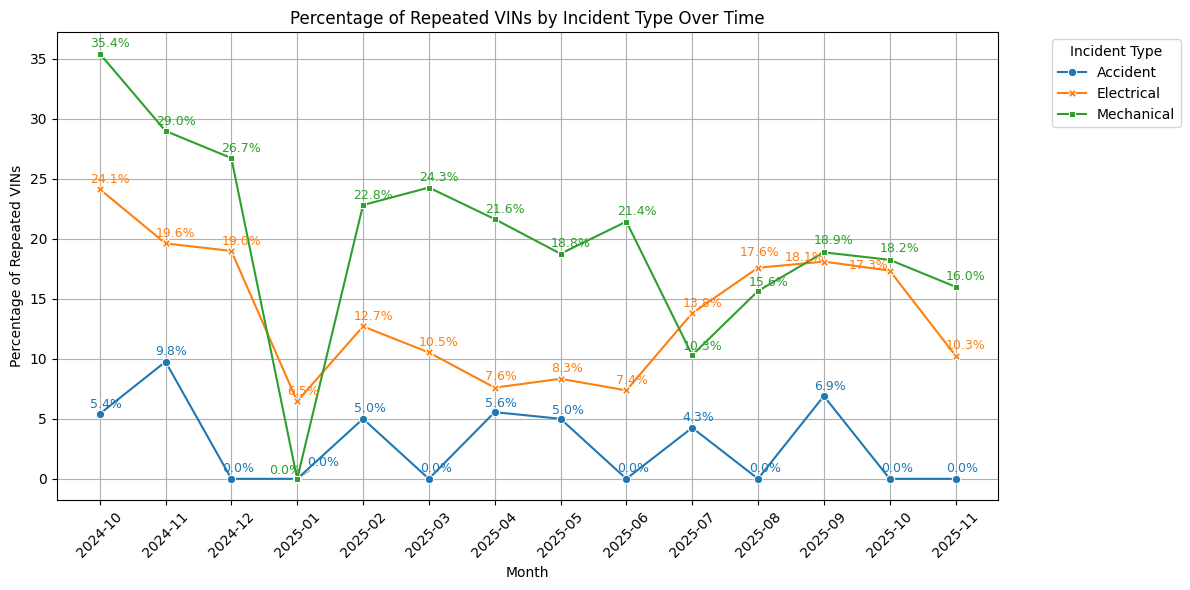

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from adjustText import adjust_text  # Import adjustText for better label positioning

# Ensure 'Incident Date' is in datetime format
data['Incident Date'] = pd.to_datetime(data['Incident Date'])
data['Month'] = data['Incident Date'].dt.to_period('M').astype(str)  # Convert Period to String

# Calculate repeated VINs per Incident Type and Month
incident_type_vin_counts = data.groupby(['Month', 'Incident Type', 'vin'])['vin'].count().reset_index(name='VIN_Count')
incident_type_total_vins = incident_type_vin_counts.groupby(['Month', 'Incident Type'])['VIN_Count'].sum().reset_index(name='Total_VINS')

incident_type_repeated_vins = (
    incident_type_vin_counts[incident_type_vin_counts['VIN_Count'] > 1]
    .groupby(['Month', 'Incident Type'])['VIN_Count']
    .sum()
    .reset_index(name='Repeated_VINS')
)

# Merge and handle missing values
merged_incident_type_data = pd.merge(incident_type_total_vins, incident_type_repeated_vins, on=['Month', 'Incident Type'], how='left')
merged_incident_type_data['Repeated_VINS'].fillna(0, inplace=True)
merged_incident_type_data['Repeated_VIN_Percentage'] = (merged_incident_type_data['Repeated_VINS'] / merged_incident_type_data['Total_VINS']) * 100

# Pivot to get Incident Types as separate series
pivot_df = merged_incident_type_data.pivot(index='Month', columns='Incident Type', values='Repeated_VIN_Percentage')

# Plot line graph with multiple series
plt.figure(figsize=(12, 6))
ax = sns.lineplot(data=pivot_df, markers=True, dashes=False)

# Adding Data Labels
texts = []  # Store text labels for adjustment
for line, incident_type in zip(ax.lines, pivot_df.columns):
    for x, y in zip(pivot_df.index, line.get_ydata()):
        if not pd.isna(y):  # Skip NaN values
            text = ax.text(x, y, f"{y:.1f}%", ha='center', va='bottom', fontsize=9, color=line.get_color())
            texts.append(text)

# Adjust text to avoid overlap
adjust_text(texts, arrowprops=dict(arrowstyle='-', color='gray', lw=0.5))

# Formatting the graph
plt.xlabel('Month')
plt.ylabel('Percentage of Repeated VINs')
plt.title('Percentage of Repeated VINs by Incident Type Over Time')
plt.xticks(rotation=45)
plt.legend(title='Incident Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()




# Last 6 weeks trend -count of breakdowns

In [ ]:
from datetime import datetime, timedelta
import pandas as pd

# Ensure datetime format
data['Incident Date'] = pd.to_datetime(data['Incident Date'])

# Create Year, Week, Year_Week
data['Year'] = data['Incident Date'].dt.isocalendar().year
data['Week'] = data['Incident Date'].dt.isocalendar().week
data['Year_Week'] = data['Year'].astype(str) + '-' + data['Week'].astype(str)

# Group: more accurate count using .size()
weekly_breakdowns = data.groupby('Year_Week').size().reset_index(name='Breakdown Count')

# Get latest 6 weeks based on actual Incident Dates
latest_weeks = (
    data[['Incident Date', 'Year_Week']]
    .drop_duplicates()
    .sort_values('Incident Date')
    .drop_duplicates('Year_Week', keep='last')
    .tail(6)['Year_Week']
    .tolist()
)

# Filter and sort accordingly
weekly_breakdowns = weekly_breakdowns[weekly_breakdowns['Year_Week'].isin(latest_weeks)]
weekly_breakdowns['Year'] = weekly_breakdowns['Year_Week'].str.split('-').str[0].astype(int)
weekly_breakdowns['Week'] = weekly_breakdowns['Year_Week'].str.split('-').str[1].astype(int)
weekly_breakdowns = weekly_breakdowns.sort_values(by=['Year', 'Week']).drop(columns=['Year', 'Week'])

# Display result
print("Breakdowns by Week (Past 6 Weeks):")
print(weekly_breakdowns)




Breakdowns by Week (Past 6 Weeks):
   Year_Week  Breakdown Count
47   2025-40               37
48   2025-41               69
49   2025-42               62
50   2025-43               68
51   2025-44               65
52   2025-45              111


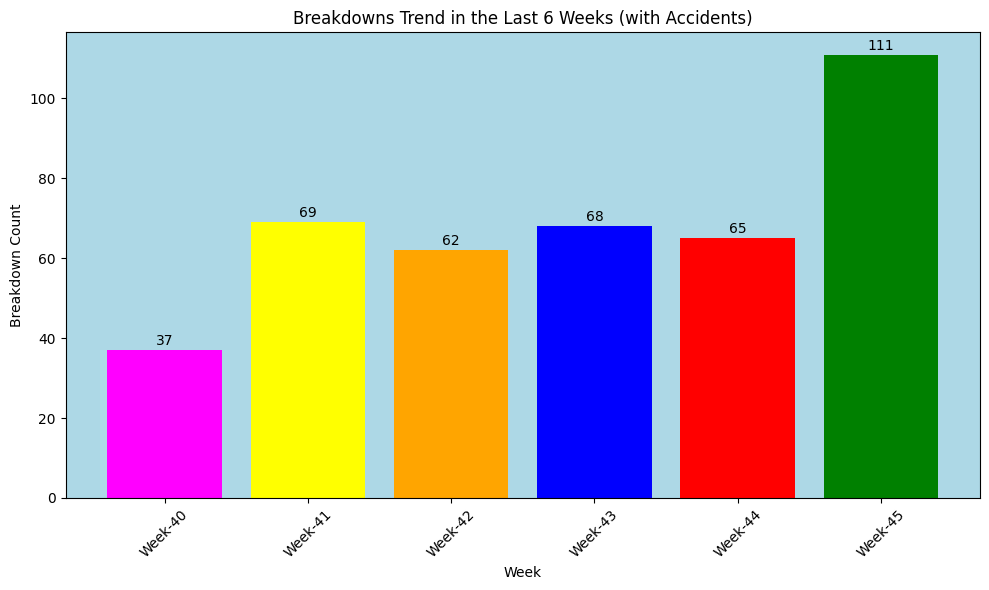

In [ ]:
import matplotlib.pyplot as plt

# Extract Year and Week for proper numerical sorting
weekly_breakdowns['Year'] = weekly_breakdowns['Year_Week'].apply(lambda x: int(x.split('-')[0]))
weekly_breakdowns['Week'] = weekly_breakdowns['Year_Week'].apply(lambda x: int(x.split('-')[1]))

# Sort by Year and Week in ascending order
weekly_breakdowns = weekly_breakdowns.sort_values(by=['Year', 'Week'])

# Format x-axis labels as "Week-x"
weekly_breakdowns['Week_Label'] = weekly_breakdowns['Week'].apply(lambda x: f'Week-{x}')

# Define colors for the bars
colors = ['magenta', 'yellow', 'orange', 'blue', 'red', 'green']

# Create a bar chart
plt.figure(figsize=(10, 6))
bars = plt.bar(weekly_breakdowns['Week_Label'], weekly_breakdowns['Breakdown Count'], color=colors)

# Add titles and labels
plt.xlabel('Week')
plt.ylabel('Breakdown Count')
plt.title('Breakdowns Trend in the Last 6 Weeks (with Accidents)')

# Add data labels on top of each bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, yval + 0.5, int(yval), ha='center', va='bottom', fontsize=10)

# Set a light blue background for the plot
plt.gca().set_facecolor('lightblue')

# Adjust tick labels and layout
plt.xticks(rotation=45)
plt.tight_layout()

# Show the plot
plt.show()


In [ ]:
import pandas as pd
from datetime import timedelta

# Ensure 'Incident Date' is in datetime format
data['Incident Date'] = pd.to_datetime(data['Incident Date'])

# ✅ Filter out rows where 'Incident Type' is 'Accident' (case- and space-insensitive)
data.columns = data.columns.str.strip()
no_accidents_data = data[~data['Incident Type'].str.strip().str.lower().eq('accident')].copy()

# ✅ Calculate Year, Week, and Year_Week using ISO calendar
iso_calendar = no_accidents_data['Incident Date'].dt.isocalendar()
no_accidents_data['Year'] = iso_calendar.year
no_accidents_data['Week'] = iso_calendar.week
no_accidents_data['Year_Week'] = no_accidents_data['Year'].astype(str) + '-' + no_accidents_data['Week'].astype(str).str.zfill(2)

# ✅ Group by Year_Week
weekly_breakdowns = (
    no_accidents_data.groupby('Year_Week')['ID'].count().reset_index()
    .rename(columns={'ID': 'Breakdown Count'})
)

# ✅ Determine 6-week range from latest date
end_date = no_accidents_data['Incident Date'].max()
start_date = end_date - pd.DateOffset(weeks=5)

# Generate list of 6 Year-Week labels
weeks_to_show = []
current_week_date = start_date

while current_week_date <= end_date:
    iso = current_week_date.isocalendar()
    week_label = f"{iso.year}-{str(iso.week).zfill(2)}"
    if week_label not in weeks_to_show:
        weeks_to_show.append(week_label)
    current_week_date += timedelta(weeks=1)

# ✅ Filter weekly data to last 6 weeks only
weekly_breakdowns = weekly_breakdowns[weekly_breakdowns['Year_Week'].isin(weeks_to_show)].copy()

# ✅ Add back Year and Week for sorting
weekly_breakdowns['Year'] = weekly_breakdowns['Year_Week'].str[:4].astype(int)
weekly_breakdowns['Week'] = weekly_breakdowns['Year_Week'].str[-2:].astype(int)

weekly_breakdowns = weekly_breakdowns.sort_values(by=['Year', 'Week']).drop(columns=['Year', 'Week'])

# ✅ Display
print("Breakdowns by Week (Past 6 Weeks) - Without Accidents:")
display(weekly_breakdowns)


Breakdowns by Week (Past 6 Weeks) - Without Accidents:


,Year_Week,Breakdown Count
52,2025-40,32
53,2025-41,61
54,2025-42,58
55,2025-43,64
56,2025-44,56
57,2025-45,100


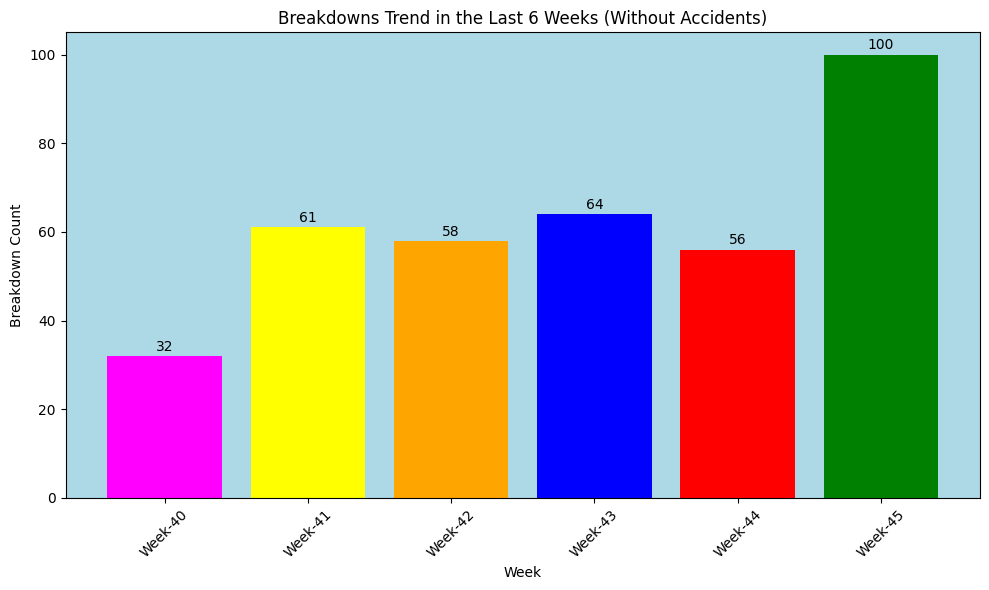

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from datetime import timedelta

# Ensure 'Incident Date' is in datetime format
data['Incident Date'] = pd.to_datetime(data['Incident Date'])

# Clean column names
data.columns = data.columns.str.strip()

# Filter out rows where 'Incident Type' is 'Accident'
no_accidents_data = data[~data['Incident Type'].str.strip().str.lower().eq('accident')].copy()

# Calculate Year, Week, and Year_Week using ISO calendar
iso_calendar = no_accidents_data['Incident Date'].dt.isocalendar()
no_accidents_data['Year'] = iso_calendar.year
no_accidents_data['Week'] = iso_calendar.week
no_accidents_data['Year_Week'] = no_accidents_data['Year'].astype(str) + '-' + no_accidents_data['Week'].astype(str).str.zfill(2)

# Group by Year_Week
weekly_breakdowns = (
    no_accidents_data.groupby('Year_Week')['ID'].count().reset_index()
    .rename(columns={'ID': 'Breakdown Count'})
)

# Determine 6-week range from latest date
end_date = no_accidents_data['Incident Date'].max()
start_date = end_date - pd.DateOffset(weeks=5)

# Generate list of 6 Year-Week labels
weeks_to_show = []
current_week_date = start_date

while current_week_date <= end_date:
    iso = current_week_date.isocalendar()
    week_label = f"{iso.year}-{str(iso.week).zfill(2)}"
    if week_label not in weeks_to_show:
        weeks_to_show.append(week_label)
    current_week_date += timedelta(weeks=1)

# Filter weekly data to last 6 weeks only
weekly_breakdowns = weekly_breakdowns[weekly_breakdowns['Year_Week'].isin(weeks_to_show)].copy()

# Extract Week number and create a simplified label
weekly_breakdowns['Year'] = weekly_breakdowns['Year_Week'].apply(lambda x: int(x.split('-')[0]))
weekly_breakdowns['Week'] = weekly_breakdowns['Year_Week'].apply(lambda x: int(x.split('-')[1]))
weekly_breakdowns['Week_Label'] = weekly_breakdowns['Week'].apply(lambda x: f"Week-{x}")

# Sort and drop extra columns
weekly_breakdowns = weekly_breakdowns.sort_values(by=['Year', 'Week']).drop(columns=['Year', 'Week', 'Year_Week'])

# Define colors dynamically
colors = ['magenta', 'yellow', 'orange', 'blue', 'red', 'green']
colors = colors[:len(weekly_breakdowns)]

# Create the bar plot
plt.figure(figsize=(10, 6))
bars = plt.bar(
    weekly_breakdowns['Week_Label'],
    weekly_breakdowns['Breakdown Count'],
    color=colors
)

plt.xlabel('Week')
plt.ylabel('Breakdown Count')
plt.title('Breakdowns Trend in the Last 6 Weeks (Without Accidents)')

# Add data labels
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, yval + 0.5, int(yval), ha='center', va='bottom', fontsize=10)

plt.gca().set_facecolor('lightblue')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


<Figure size 1600x800 with 0 Axes>

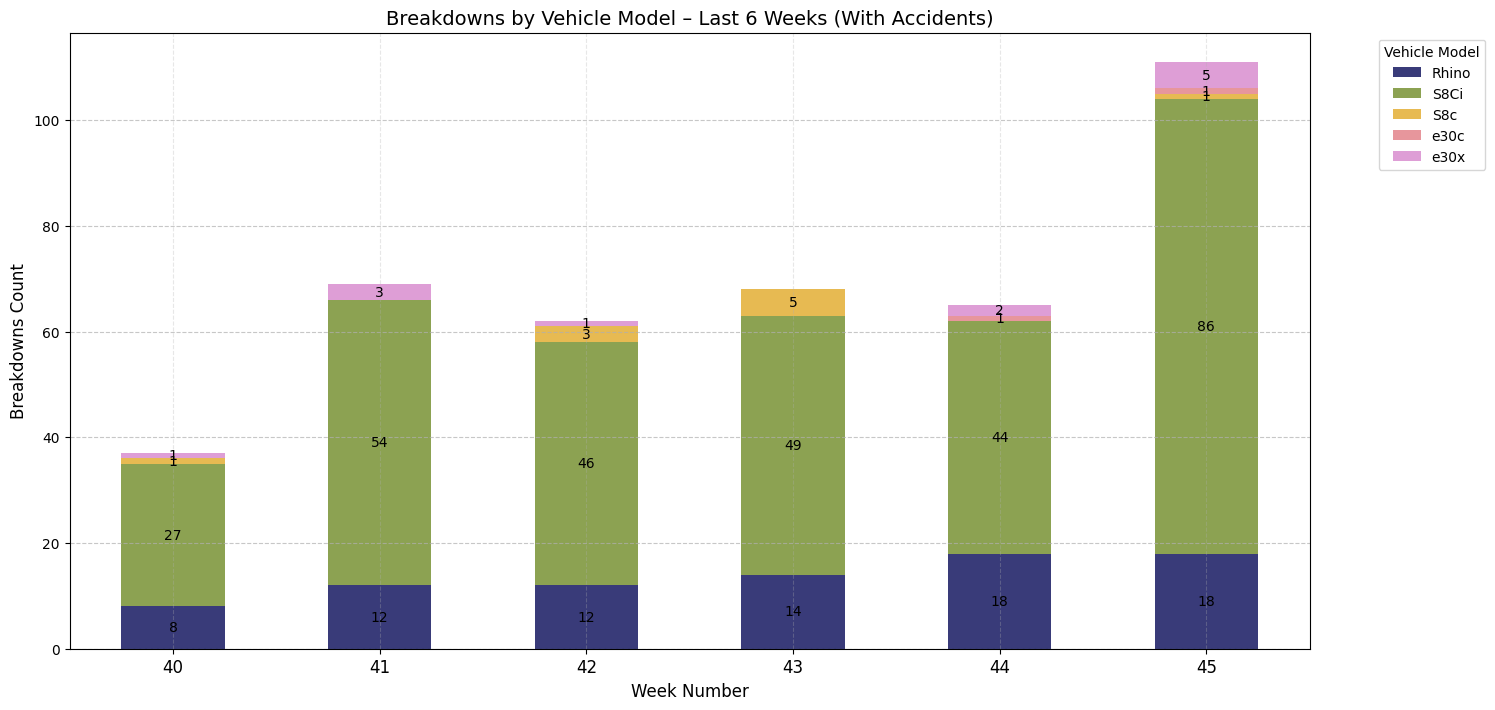

In [ ]:
# Generalized code: Show breakdowns by vehicle model for the last 6 weeks (with accidents)

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

# Ensure 'Incident Date' is in datetime format
data['Incident Date'] = pd.to_datetime(data['Incident Date'])

# Get ISO week and year
iso_calendar = data['Incident Date'].dt.isocalendar()
data['Year'] = iso_calendar.year
data['Week'] = iso_calendar.week
data['Year_Week'] = data['Year'].astype(str) + '-' + data['Week'].astype(str).str.zfill(2)

# Find the last 6 unique weeks based on Incident Date
latest_weeks = (
    data[['Incident Date', 'Year_Week']]
    .drop_duplicates()
    .sort_values('Incident Date')
    .drop_duplicates('Year_Week', keep='last')
    .tail(6)['Year_Week']
    .tolist()
)

# Filter for only those last 6 weeks
filtered_data_6w = data[data['Year_Week'].isin(latest_weeks)].copy()

# Group by Year_Week and Vehicle Model
weekly_model_breakdowns = filtered_data_6w.groupby(['Year_Week', 'Vehicle Model'])['ID'].count().reset_index(name='Breakdown Count')

# Pivot for stacked bars
pivot_df = weekly_model_breakdowns.pivot(index='Year_Week', columns='Vehicle Model', values='Breakdown Count').fillna(0)

# Sort weeks in order
weeks_order = latest_weeks
pivot_df = pivot_df.loc[weeks_order]

# Change x-axis labels to just week number
week_labels = [wk.split('-')[1] for wk in weeks_order]
pivot_df.index = week_labels

# Color palette
colors = cm.tab20b(np.linspace(0, 1, len(pivot_df.columns)))
model_colors = dict(zip(pivot_df.columns, colors))

# Plot stacked bar chart
plt.figure(figsize=(16, 8))
ax = pivot_df.plot(kind='bar', stacked=True, figsize=(16, 8), color=model_colors)

# Add data labels
for container in ax.containers:
    labels = [f'{int(h.get_height())}' if h.get_height() > 0 else '' for h in container]
    ax.bar_label(container, labels=labels, label_type='center', fontsize=10)

# Title and labels
plt.xlabel('Week Number', fontsize=12)
plt.ylabel('Breakdowns Count', fontsize=12)
plt.title('Breakdowns by Vehicle Model – Last 6 Weeks (With Accidents)', fontsize=14)
plt.xticks(rotation=0, fontsize=12, color='black')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.legend(title='Vehicle Model', bbox_to_anchor=(1.05, 1), loc='upper left')

<Figure size 1600x800 with 0 Axes>

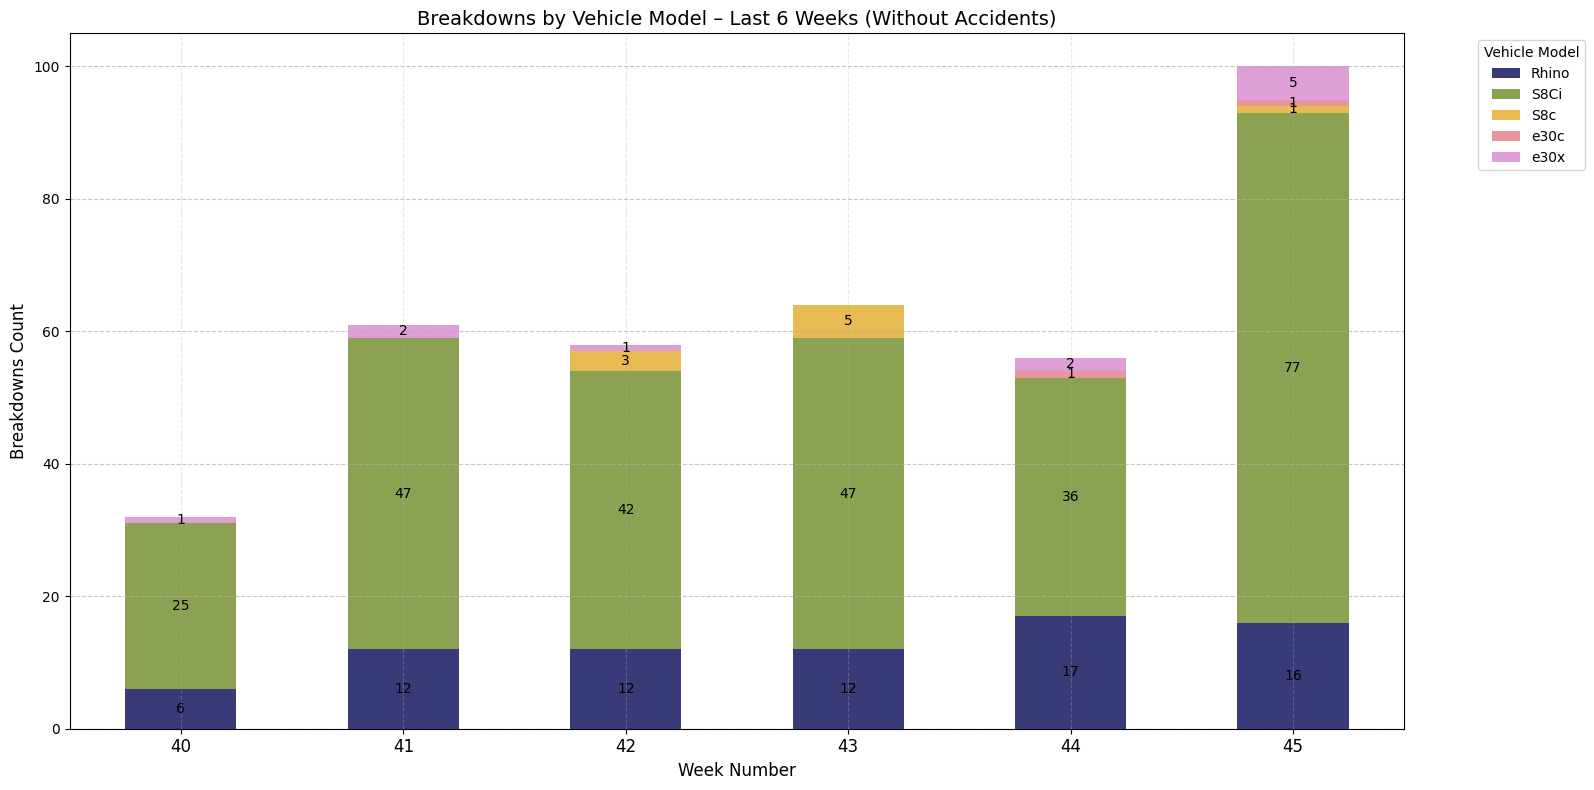

In [ ]:
# Generalized code: Show breakdowns by vehicle model for the last 6 weeks (without accidents)

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

# Ensure 'Incident Date' is in datetime format
data['Incident Date'] = pd.to_datetime(data['Incident Date'])

# Exclude "Accident" incidents
filtered_data = data[data['Incident Type'].str.strip().str.lower() != 'accident'].copy()

# Get ISO week and year
iso_calendar = filtered_data['Incident Date'].dt.isocalendar()
filtered_data['Year'] = iso_calendar.year
filtered_data['Week'] = iso_calendar.week
filtered_data['Year_Week'] = filtered_data['Year'].astype(str) + '-' + filtered_data['Week'].astype(str).str.zfill(2)

# Find the last 6 unique weeks based on Incident Date
latest_weeks = (
    filtered_data[['Incident Date', 'Year_Week']]
    .drop_duplicates()
    .sort_values('Incident Date')
    .drop_duplicates('Year_Week', keep='last')
    .tail(6)['Year_Week']
    .tolist()
)

# Filter for only those last 6 weeks
filtered_data_6w = filtered_data[filtered_data['Year_Week'].isin(latest_weeks)].copy()

# Group by Year_Week and Vehicle Model
weekly_model_breakdowns = filtered_data_6w.groupby(['Year_Week', 'Vehicle Model'])['ID'].count().reset_index(name='Breakdown Count')

# Pivot for stacked bars
pivot_df = weekly_model_breakdowns.pivot(index='Year_Week', columns='Vehicle Model', values='Breakdown Count').fillna(0)

# Sort weeks in order
weeks_order = latest_weeks
pivot_df = pivot_df.loc[weeks_order]

# Change x-axis labels to just week number
week_labels = [wk.split('-')[1] for wk in weeks_order]
pivot_df.index = week_labels

# Color palette
colors = cm.tab20b(np.linspace(0, 1, len(pivot_df.columns)))
model_colors = dict(zip(pivot_df.columns, colors))

# Plot stacked bar chart
plt.figure(figsize=(16, 8))
ax = pivot_df.plot(kind='bar', stacked=True, figsize=(16, 8), color=model_colors)

# Add data labels
for container in ax.containers:
    labels = [f'{int(h.get_height())}' if h.get_height() > 0 else '' for h in container]
    ax.bar_label(container, labels=labels, label_type='center', fontsize=10)

# Title and labels
plt.xlabel('Week Number', fontsize=12)
plt.ylabel('Breakdowns Count', fontsize=12)
plt.title('Breakdowns by Vehicle Model – Last 6 Weeks (Without Accidents)', fontsize=14)
plt.xticks(rotation=0, fontsize=12, color='black')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.legend(title='Vehicle Model', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

# Last 1 year breakdowns analysis

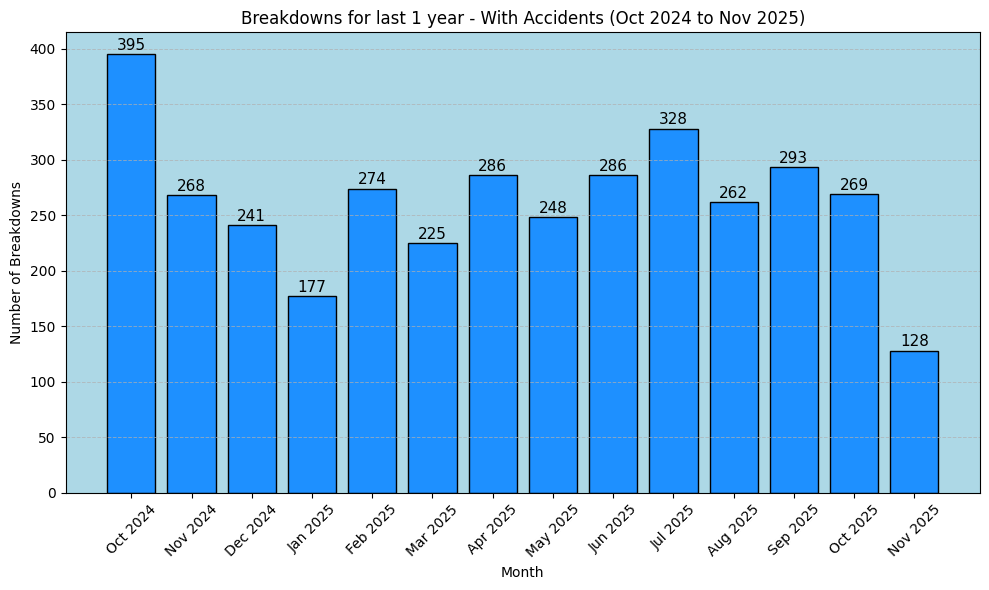

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Ensure 'Incident Date' is in datetime format
data['Incident Date'] = pd.to_datetime(data['Incident Date'])

# Group by year and month (to avoid data shifting issues)
monthly_breakdowns = data.groupby(data['Incident Date'].dt.to_period('M'))['ID'].count()

# Convert the grouped index back to a proper datetime index
monthly_breakdowns.index = monthly_breakdowns.index.to_timestamp()

# Filter data from April 2024 to July 2025
monthly_breakdowns = monthly_breakdowns[(monthly_breakdowns.index >= '2024-09-01') & (monthly_breakdowns.index <= '2025-11-30')]

# Create a bar graph
plt.figure(figsize=(10, 6))
bars = plt.bar(monthly_breakdowns.index.strftime('%b %Y'), monthly_breakdowns.values, color='dodgerblue', edgecolor='black')

# Add labels and title
plt.xlabel('Month')
plt.ylabel('Number of Breakdowns')
plt.title('Breakdowns for last 1 year - With Accidents (Oct 2024 to Nov 2025)')

# Add data labels on top of each bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, yval + 1, int(yval), ha='center', va='bottom', fontsize=11)



# Rotate x-axis labels for better readability
plt.xticks(rotation=45)

# Add grid and background styling
plt.grid(axis='y', linestyle='--', linewidth=0.7, alpha=0.7)
plt.gca().set_facecolor('lightblue')

plt.tight_layout()
plt.show()


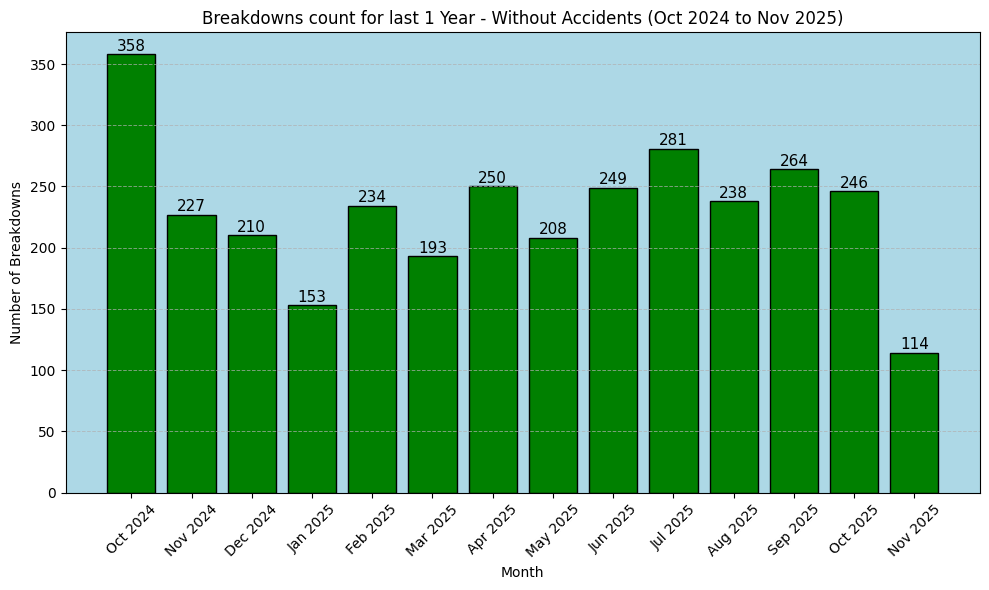

In [ ]:


# Ensure 'Incident Date' is in datetime format
data['Incident Date'] = pd.to_datetime(data['Incident Date'])

# Filter out accidents
data_without_accidents = data[data['Incident Type'] != 'Accident']

# Group by year and month (to avoid data shifting issues)
monthly_breakdowns = data_without_accidents.groupby(data_without_accidents['Incident Date'].dt.to_period('M'))['ID'].count()

# Convert the grouped index back to a proper datetime index
monthly_breakdowns.index = monthly_breakdowns.index.to_timestamp()

# Filter data from April 2024 to January 2025
monthly_breakdowns = monthly_breakdowns[(monthly_breakdowns.index >= '2024-09-01') & (monthly_breakdowns.index <= '2025-11-30')]

# Create a bar graph
plt.figure(figsize=(10, 6))
bars = plt.bar(monthly_breakdowns.index.strftime('%b %Y'), monthly_breakdowns.values, color='green', edgecolor='black')

# Add labels and title
plt.xlabel('Month')
plt.ylabel('Number of Breakdowns')
plt.title('Breakdowns count for last 1 Year - Without Accidents (Oct 2024 to Nov 2025)')

# Add data labels on top of each bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, yval + 0.5, int(yval), ha='center', va='bottom', fontsize=11)


# Rotate x-axis labels for better readability
plt.xticks(rotation=45)

# Add grid and background styling
plt.grid(axis='y', linestyle='--', linewidth=0.7, alpha=0.7)
plt.gca().set_facecolor('lightblue')

plt.tight_layout()
plt.show()


### Frequency of breakdowns

In [ ]:

import io
import pandas as pd
pd.read_csv(io.StringIO('''
FON,April-24,May -24,June -24,July-24,Aug-24,Sept-24,Oct -24,Nov-24,Dec-24,Jan-25,Feb-25,March-25,April-25,May-25,June-25,July-25,August-25,September-25,October-25,November-25
BLR,237,226,231,242,242,228,200,149,153,142,136,138,141,145,156,157,159,210,215,224
CHN,129,130,141,154,176,173,187,210,218,226,245,253,262,279,301,314,314,322,349,358
COI,62,61,63,77,86,95,116,127,129,132,137,147,161,172,187,202,212,225,237,272
HYD,197,193,180,182,178,190,194,200,202,204,204,211,227,232,240,233,216,201,193,200
MMB,200,236,286,301,328,329,340,360,364,366,356,356,337,330,333,318,298,294,298,304
Total,825,846,901,956,1010,1015,1036,1046,1066,1070,1078,1104,1128,1158,1217,1224,1199,1252,1292,1358
'''), header=None)


,0,1,2,3,4,5,6,7,8,9,...,11,12,13,14,15,16,17,18,19,20
0,FON,April-24,May -24,June -24,July-24,Aug-24,Sept-24,Oct -24,Nov-24,Dec-24,...,Feb-25,March-25,April-25,May-25,June-25,July-25,August-25,September-25,October-25,November-25
1,BLR,237,226,231,242,242,228,200,149,153,...,136,138,141,145,156,157,159,210,215,224
2,CHN,129,130,141,154,176,173,187,210,218,...,245,253,262,279,301,314,314,322,349,358
3,COI,62,61,63,77,86,95,116,127,129,...,137,147,161,172,187,202,212,225,237,272
4,HYD,197,193,180,182,178,190,194,200,202,...,204,211,227,232,240,233,216,201,193,200
5,MMB,200,236,286,301,328,329,340,360,364,...,356,356,337,330,333,318,298,294,298,304
6,Total,825,846,901,956,1010,1015,1036,1046,1066,...,1078,1104,1128,1158,1217,1224,1199,1252,1292,1358


/tmp/ipython-input-3900764274.py:67: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(


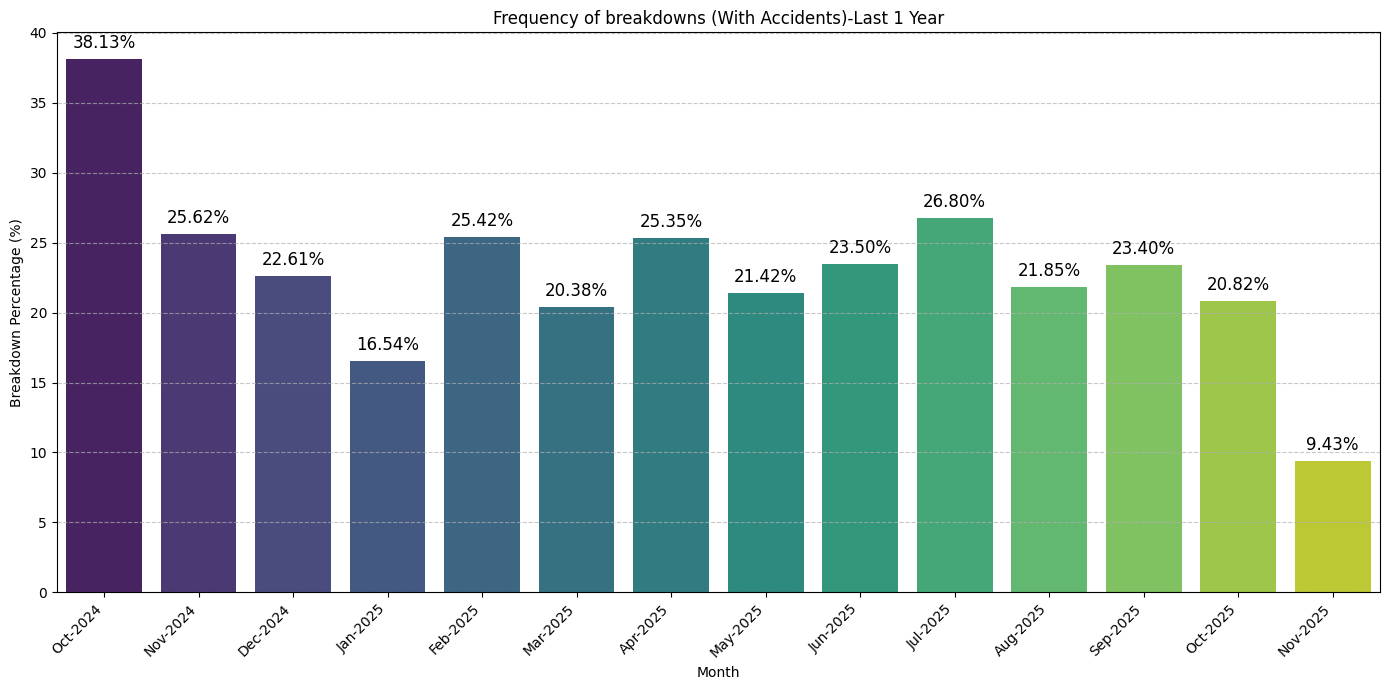

,Month,Breakdown_Count,Active_Vehicles,Breakdown_Percentage
0,Oct-2024,395,1036,38.127413
1,Nov-2024,268,1046,25.621415
2,Dec-2024,241,1066,22.607880
3,Jan-2025,177,1070,16.542056
4,Feb-2025,274,1078,25.417440
5,Mar-2025,225,1104,20.380435
6,Apr-2025,286,1128,25.354610
7,May-2025,248,1158,21.416235
8,Jun-2025,286,1217,23.500411
9,Jul-2025,328,1224,26.797386


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import io

# Read Active Vehicle data
active_vehicles_data = pd.read_csv(io.StringIO('''
FON,April-24,May -24,June -24,July-24,Aug-24,Sept-24,Oct -24,Nov-24,Dec-24,Jan-25,Feb-25,March-25,April-25,May-25,June-25,July-25,August-25,September-25,October-25,November-25
BLR,237,226,231,242,242,228,200,149,153,142,136,138,141,145,156,157,159,210,215,224
CHN,129,130,141,154,176,173,187,210,218,226,245,253,262,279,301,314,314,322,349,358
COI,62,61,63,77,86,95,116,127,129,132,137,147,161,172,187,202,212,225,237,272
HYD,197,193,180,182,178,190,194,200,202,204,204,211,227,232,240,233,216,201,193,200
MMB,200,236,286,301,328,329,340,360,364,366,356,356,337,330,333,318,298,294,298,304
Total,825,846,901,956,1010,1015,1036,1046,1066,1070,1078,1104,1128,1158,1217,1224,1199,1252,1292,1358
'''))

# Process active vehicles
monthly_active_vehicles = active_vehicles_data[active_vehicles_data['FON'] == 'Total'].drop('FON', axis=1).T.reset_index()
monthly_active_vehicles.columns = ['Month', 'Active_Vehicles']
monthly_active_vehicles['Month'] = monthly_active_vehicles['Month'].str.strip()

# Month mapping to match '%b-%Y' format
month_mapping = {
    'April-24': 'Apr-2024', 'May -24': 'May-2024', 'June -24': 'Jun-2024',
    'July-24': 'Jul-2024', 'Aug-24': 'Aug-2024', 'Sept-24': 'Sep-2024',
    'Oct -24': 'Oct-2024', 'Nov-24': 'Nov-2024', 'Dec-24': 'Dec-2024',
    'Jan-25': 'Jan-2025', 'Feb-25': 'Feb-2025', 'March-25': 'Mar-2025',
    'April-25': 'Apr-2025', 'May-25': 'May-2025', 'June-25': 'Jun-2025',
    'July-25': 'Jul-2025', 'August-25': 'Aug-2025', 'September-25': 'Sep-2025','October-25': 'Oct-2025','November-25':'Nov-2025'
}
monthly_active_vehicles['Month_Formatted'] = monthly_active_vehicles['Month'].map(month_mapping)

# Filter breakdown data for sep 24 to Oct 25
data['Incident Date'] = pd.to_datetime(data['Incident Date'])
data_filtered = data[(data['Incident Date'] >= '2024-10-01') & (data['Incident Date'] <= '2025-11-09')].copy()

# Prepare breakdown counts
monthly_breakdown_counts = data_filtered.groupby(data_filtered['Incident Date'].dt.to_period('M'))['ID'].count().reset_index()
monthly_breakdown_counts['Month'] = monthly_breakdown_counts['Incident Date'].dt.strftime('%b-%Y')
monthly_breakdown_counts.rename(columns={'ID': 'Breakdown_Count'}, inplace=True)
monthly_breakdown_counts.drop(columns='Incident Date', inplace=True)

# Merge on common months
common_months = monthly_breakdown_counts['Month'].unique()
monthly_active_vehicles_filtered = monthly_active_vehicles[monthly_active_vehicles['Month_Formatted'].isin(common_months)].copy()
monthly_breakdown_counts_filtered = monthly_breakdown_counts[monthly_breakdown_counts['Month'].isin(common_months)].copy()

# Sort by month
monthly_active_vehicles_filtered['Sort_Key'] = pd.to_datetime(monthly_active_vehicles_filtered['Month_Formatted'], format='%b-%Y')
monthly_breakdown_counts_filtered['Sort_Key'] = pd.to_datetime(monthly_breakdown_counts_filtered['Month'], format='%b-%Y')

monthly_active_vehicles_filtered = monthly_active_vehicles_filtered.sort_values('Sort_Key').drop('Sort_Key', axis=1)
monthly_breakdown_counts_filtered = monthly_breakdown_counts_filtered.sort_values('Sort_Key').drop('Sort_Key', axis=1)

# Merge and compute percentages
merged_data = pd.merge(
    monthly_breakdown_counts_filtered,
    monthly_active_vehicles_filtered[['Month_Formatted', 'Active_Vehicles']],
    left_on='Month',
    right_on='Month_Formatted',
    how='inner'
)
merged_data['Breakdown_Percentage'] = (merged_data['Breakdown_Count'] / merged_data['Active_Vehicles']) * 100

# Plot
plt.figure(figsize=(14, 7))
bars = sns.barplot(
    x='Month',
    y='Breakdown_Percentage',
    data=merged_data,
    order=merged_data['Month'].tolist(),
    palette='viridis'
)

plt.xlabel('Month')
plt.ylabel('Breakdown Percentage (%)')
plt.title('Frequency of breakdowns (With Accidents)-Last 1 Year')
plt.xticks(rotation=45, ha='right')

for bar in bars.patches:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2., yval + 0.5, f'{yval:.2f}%',
             ha='center', va='bottom', fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Display merged table
display(merged_data[['Month', 'Breakdown_Count', 'Active_Vehicles', 'Breakdown_Percentage']])

/tmp/ipython-input-2728378284.py:69: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(


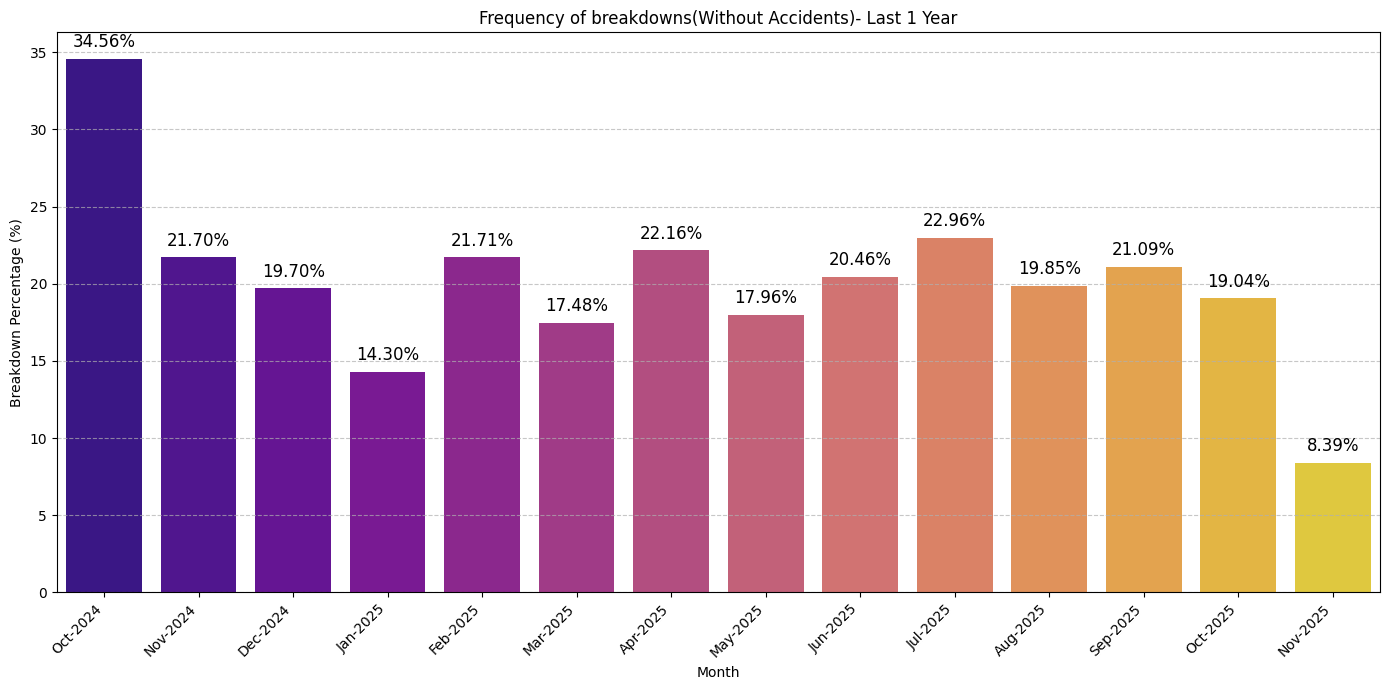

,Month_Formatted,Breakdown_Count_No_Accidents,Active_Vehicles,Breakdown_Percentage_No_Accidents
0,Oct-2024,358,1036,34.555985
1,Nov-2024,227,1046,21.701721
2,Dec-2024,210,1066,19.699812
3,Jan-2025,153,1070,14.299065
4,Feb-2025,234,1078,21.706865
5,Mar-2025,193,1104,17.481884
6,Apr-2025,250,1128,22.163121
7,May-2025,208,1158,17.962003
8,Jun-2025,249,1217,20.460148
9,Jul-2025,281,1224,22.957516


In [ ]:
# breakdown percentage without acciddents
# Step 1: Filter out accident rows
data_without_accidents = data[data['Incident Type'].str.strip().str.lower() != 'accident'].copy()
data_without_accidents['Incident Date'] = pd.to_datetime(data_without_accidents['Incident Date'])

# Step 2: Filter for Oct 2024 to November 2025
data_filtered = data_without_accidents[
    (data_without_accidents['Incident Date'] >= '2024-10-01') &
    (data_without_accidents['Incident Date'] <= '2025-11-09')
]

# Step 3: Group by month and count breakdowns
monthly_breakdowns_no_accidents = (
    data_filtered.groupby(data_filtered['Incident Date'].dt.to_period('M'))['ID']
    .count()
    .reset_index()
)
monthly_breakdowns_no_accidents['Month_Formatted'] = monthly_breakdowns_no_accidents['Incident Date'].dt.strftime('%b-%Y')

# Step 4: Load active vehicle data (includes July-25)
active_vehicles_data = pd.read_csv(io.StringIO('''
FON,April-24,May -24,June -24,July-24,Aug-24,Sept-24,Oct -24,Nov-24,Dec-24,Jan-25,Feb-25,March-25,April-25,May-25,June-25,July-25,August-25,September-25,October-25,November-25
BLR,237,226,231,242,242,228,200,149,153,142,136,138,141,145,156,157,159,210,215,224
CHN,129,130,141,154,176,173,187,210,218,226,245,253,262,279,301,314,314,322,349,358
COI,62,61,63,77,86,95,116,127,129,132,137,147,161,172,187,202,212,225,237,272
HYD,197,193,180,182,178,190,194,200,202,204,204,211,227,232,240,233,216,201,193,200
MMB,200,236,286,301,328,329,340,360,364,366,356,356,337,330,333,318,298,294,298,304
Total,825,846,901,956,1010,1015,1036,1046,1066,1070,1078,1104,1128,1158,1217,1224,1199,1252,1292,1358
'''))

# Step 5: Format active vehicle data
active = active_vehicles_data[active_vehicles_data['FON'] == 'Total'].drop('FON', axis=1).T.reset_index()
active.columns = ['Month', 'Active_Vehicles']
active['Month'] = active['Month'].str.strip()

# Step 6: Month mapping for formatting
month_mapping = {
    'Oct -24': 'Oct-2024', 'Nov-24': 'Nov-2024', 'Dec-24': 'Dec-2024',
    'Jan-25': 'Jan-2025', 'Feb-25': 'Feb-2025', 'March-25': 'Mar-2025',
    'April-25': 'Apr-2025', 'May-25': 'May-2025', 'June-25': 'Jun-2025',
    'July-25': 'Jul-2025', 'August-25': 'Aug-2025', 'September-25': 'Sep-2025', 'October-25': 'Oct-2025','November-25':'Nov-2025'
}
active['Month_Formatted'] = active['Month'].map(month_mapping)

# Step 7: Merge breakdown and active vehicle data
merged = pd.merge(
    monthly_breakdowns_no_accidents[['Month_Formatted', 'ID']],
    active[['Month_Formatted', 'Active_Vehicles']],
    on='Month_Formatted',
    how='inner'
)
merged.rename(columns={'ID': 'Breakdown_Count_No_Accidents'}, inplace=True)

# Step 8: Calculate percentage
merged['Breakdown_Percentage_No_Accidents'] = (
    merged['Breakdown_Count_No_Accidents'] / merged['Active_Vehicles']
) * 100

# Step 9: Sort months
month_order = [
       'Oct-2024', 'Nov-2024', 'Dec-2024',
    'Jan-2025', 'Feb-2025', 'Mar-2025', 'Apr-2025', 'May-2025', 'Jun-2025', 'Jul-2025', 'Aug-2025', 'Sep-2025','Oct-2025','Nov-2025'
]
merged['Month_Formatted'] = pd.Categorical(merged['Month_Formatted'], categories=month_order, ordered=True)
merged = merged.sort_values('Month_Formatted')

# Step 10: Plot
plt.figure(figsize=(14, 7))
bars = sns.barplot(
    x='Month_Formatted',
    y='Breakdown_Percentage_No_Accidents',
    data=merged,
    palette='plasma'
)

plt.xlabel('Month')
plt.ylabel('Breakdown Percentage (%)')
plt.title('Frequency of breakdowns(Without Accidents)- Last 1 Year')
plt.xticks(rotation=45, ha='right')

# Add value labels
for bar in bars.patches:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2.,
        yval + 0.5,
        f'{yval:.2f}%',
        ha='center',
        va='bottom',
        fontsize=12
    )

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Step 11: Display final table
display(merged[['Month_Formatted', 'Breakdown_Count_No_Accidents', 'Active_Vehicles', 'Breakdown_Percentage_No_Accidents']])


### Breakdowns v/s active vehicles

In [ ]:
import io
import pandas as pd
pd.read_csv(io.StringIO('''
FON,April-24,May -24,June -24,July-24,Aug-24,Sept-24,Oct -24,Nov-24,Dec-24,Jan-25,Feb-25,March-25,April-25,May-25,June-25,July-25,August-25,September-25,October-25,November-25
BLR,237,226,231,242,242,228,200,149,153,142,136,138,141,145,156,157,159,210,215,224
CHN,129,130,141,154,176,173,187,210,218,226,245,253,262,279,301,314,314,322,349,358
COI,62,61,63,77,86,95,116,127,129,132,137,147,161,172,187,202,212,225,237,272
HYD,197,193,180,182,178,190,194,200,202,204,204,211,227,232,240,233,216,201,193,200
MMB,200,236,286,301,328,329,340,360,364,366,356,356,337,330,333,318,298,294,298,304
Total,825,846,901,956,1010,1015,1036,1046,1066,1070,1078,1104,1128,1158,1217,1224,1199,1252,1292,1358
'''), header=None)


,0,1,2,3,4,5,6,7,8,9,...,11,12,13,14,15,16,17,18,19,20
0,FON,April-24,May -24,June -24,July-24,Aug-24,Sept-24,Oct -24,Nov-24,Dec-24,...,Feb-25,March-25,April-25,May-25,June-25,July-25,August-25,September-25,October-25,November-25
1,BLR,237,226,231,242,242,228,200,149,153,...,136,138,141,145,156,157,159,210,215,224
2,CHN,129,130,141,154,176,173,187,210,218,...,245,253,262,279,301,314,314,322,349,358
3,COI,62,61,63,77,86,95,116,127,129,...,137,147,161,172,187,202,212,225,237,272
4,HYD,197,193,180,182,178,190,194,200,202,...,204,211,227,232,240,233,216,201,193,200
5,MMB,200,236,286,301,328,329,340,360,364,...,356,356,337,330,333,318,298,294,298,304
6,Total,825,846,901,956,1010,1015,1036,1046,1066,...,1078,1104,1128,1158,1217,1224,1199,1252,1292,1358


In [ ]:
# table for count of breakdowns month wise and FON, mention month name and replace null with zero

# Group by month and FON, then count breakdowns
monthly_fon_breakdowns = data.groupby([data['Incident Date'].dt.month, 'FON'])['ID'].count().unstack().fillna(0)

# Replace month numbers with names
month_names = {
    4: 'April',
    5: 'May',
    6: 'June',
    7: 'July',
    8: 'August',
    9: 'September',
    10: 'October',
    11: 'November',
    12: 'December',
    1: 'January',
    2: 'February',
    3: 'March'


}
monthly_fon_breakdowns = monthly_fon_breakdowns.rename(index=month_names)

# Display the table
print("Count of Breakdowns Month-wise and by FON:")
print(monthly_fon_breakdowns)


Count of Breakdowns Month-wise and by FON:
FON            BLR  CHN  COI  HYD  MMB
Incident Date                         
January         35   42   15   32   53
February        27   73   25   34  115
March           42   57   10   49   67
April           38   92   11   32  113
May             49   42   21   26  110
June            52   65    5   19  145
July            42   64    5   58  159
August          25   98    6   25  108
September       29  121    2   41  100
October        115  111    8   83  347
November        63   94   23   39  177
December        45   67   23   32   74


In [ ]:
# Import necessary libraries
import pandas as pd
from ipywidgets import interact
import ipywidgets as widgets
from IPython.display import display

# Add Year and Month columns
data['Year'] = data['Incident Date'].dt.year
data['Month'] = data['Incident Date'].dt.month

# Group by FON, Year, and Month, and count IDs
fon_year_month_breakdowns = data.groupby(['FON', 'Year', 'Month'])['ID'].count()
fon_year_month_breakdowns = fon_year_month_breakdowns.unstack(level='Month')  # Columns = Months

# Function to display table for a selected year
def show_table_by_year_and_month(year, month):
    """Displays the breakdown table for the selected year and month."""
    subset = fon_year_month_breakdowns.loc[fon_year_month_breakdowns.index.get_level_values('Year') == year]
    if month in subset.columns:
        display(subset[[month]])
    else:
        print("No data available for the selected month.")

# Create dropdowns
year_dropdown = widgets.Dropdown(
    options=sorted(data['Year'].unique()),
    description='Year:',
    value=data['Year'].min()
)

month_dropdown = widgets.Dropdown(
    options=range(1, 13),
    description='Month:',
    value=4  # Default to April
)

# Interactive view
interact(show_table_by_year_and_month, year=year_dropdown, month=month_dropdown);



interactive(children=(Dropdown(description='Year:', options=(np.int32(2024), np.int32(2025)), value=np.int32(2…

In [ ]:
#Without accidents
#  Step 1: Filter out accidents
data_no_accidents = data[data['Incident Type'] != 'Accident']

# Step 2: Extract Year and Month from 'Incident Date'
data_no_accidents['Year'] = data_no_accidents['Incident Date'].dt.year
data_no_accidents['Month'] = data_no_accidents['Incident Date'].dt.month

# Step 3: Group by FON, Year, and Month and count IDs
fon_year_month_no_accidents = data_no_accidents.groupby(['FON', 'Year', 'Month'])['ID'].count()
fon_year_month_no_accidents = fon_year_month_no_accidents.unstack(level='Month')  # Columns = Months

# Step 4: Define interactive display function
def show_table_no_accidents_by_year_and_month(year, month):
    """Displays the breakdowns table for the selected year and month (excluding accidents)."""
    subset = fon_year_month_no_accidents.loc[fon_year_month_no_accidents.index.get_level_values('Year') == year]
    if month in subset.columns:
        display(subset[[month]])
    else:
        print("No data available for the selected month.")

# Step 5: Create interactive dropdowns
year_dropdown_no_accidents = widgets.Dropdown(
    options=sorted(data_no_accidents['Year'].unique()),
    value=data_no_accidents['Year'].min(),
    description='Year:',
)

month_dropdown_no_accidents = widgets.Dropdown(
    options=range(1, 13),
    value=4,  # Default April
    description='Month:',
)

# Step 6: Display interactive widget
interact(show_table_no_accidents_by_year_and_month, year=year_dropdown_no_accidents, month=month_dropdown_no_accidents);


/tmp/ipython-input-4285028823.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_no_accidents['Year'] = data_no_accidents['Incident Date'].dt.year
/tmp/ipython-input-4285028823.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_no_accidents['Month'] = data_no_accidents['Incident Date'].dt.month


interactive(children=(Dropdown(description='Year:', options=(np.int32(2024), np.int32(2025)), value=np.int32(2…

In [ ]:

import io
import pandas as pd
pd.read_csv(io.StringIO('''
Year,Months,BLR,CHN,COI,HYD,MMB
2024,May 24,25.22%,68.46%,3.28%,19.17%,35.17%
2024,June 24,25.11%,55.32%,0.00%,20.00%,19.93%
2024,July 24,36.78%,39.61%,2.20%,46.75%,65.78%
2024,Aug 24,50.83%,32.95%,8.14%,23.60%,69.82%
2024,Sep 24,38.16%,21.51%,6.38%,14.14%,50.00%
2024,Oct 24,49.47%,33.14%,2.59%,18.09%,57.72%
2024,Nov 24,35.57%,29.05%,18.06%,13.00%,29.47%
2024,Dec 24,29.61%,30.73%,17.69%,15.61%,20.22%
2025,Jan 25,24.65%,18.58%,11.36%,15.69%,14.48%
2025,Feb 25,19.84%,29.80%,18.25%,16.67%,32.30%
2025,March 25,30.43%,22.53%,6.80%,23.22%,18.82%
2025,April 25,26.95%,35.11%,6.83%,14.10%,33.53%
2025,May 25,33.79%,15.05%,12.21%,11.21%,33.33%
2025,June 25,33.33%,20.60%,2.67%,7.92%,41.74%
2025,July 25,26.75%,20.38%,2.48%,24.89%,50.00%
2025,August -25,15.72%,31.21%,2.83%,11.57%,36.24%
2025,Sept-25,13.81%,37.58%,0.89%,20.40%,34.01%
2025,Oct-25,7.44%,14.04%,2.11%,24.87%,50.67%
2025,Nov-25,4.46%,9.50%,0.00%,6.50%,23.36%
'''), header=None)


,0,1,2,3,4,5,6
0,Year,Months,BLR,CHN,COI,HYD,MMB
1,2024,May 24,25.22%,68.46%,3.28%,19.17%,35.17%
2,2024,June 24,25.11%,55.32%,0.00%,20.00%,19.93%
3,2024,July 24,36.78%,39.61%,2.20%,46.75%,65.78%
4,2024,Aug 24,50.83%,32.95%,8.14%,23.60%,69.82%
5,2024,Sep 24,38.16%,21.51%,6.38%,14.14%,50.00%
6,2024,Oct 24,49.47%,33.14%,2.59%,18.09%,57.72%
7,2024,Nov 24,35.57%,29.05%,18.06%,13.00%,29.47%
8,2024,Dec 24,29.61%,30.73%,17.69%,15.61%,20.22%
9,2025,Jan 25,24.65%,18.58%,11.36%,15.69%,14.48%


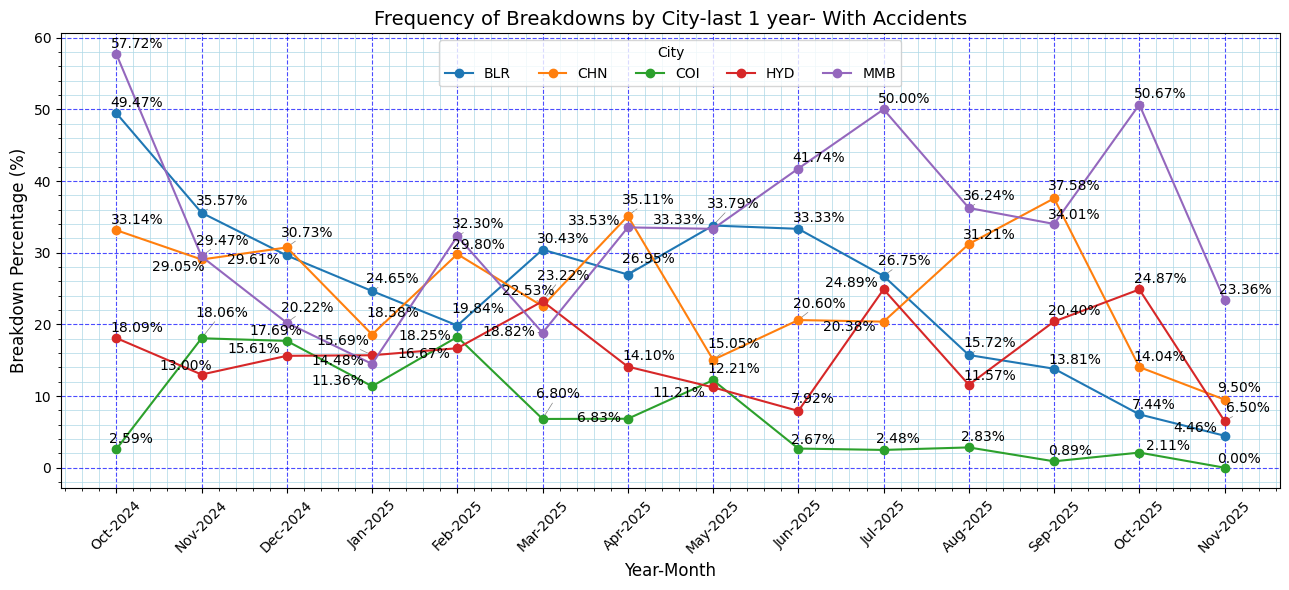

In [ ]:
# Data with percentage values (with accidents)
data1 = '''
Year,Months,BLR,CHN,COI,HYD,MMB
2024,Oct 24,49.47%,33.14%,2.59%,18.09%,57.72%
2024,Nov 24,35.57%,29.05%,18.06%,13.00%,29.47%
2024,Dec 24,29.61%,30.73%,17.69%,15.61%,20.22%
2025,Jan 25,24.65%,18.58%,11.36%,15.69%,14.48%
2025,Feb 25,19.84%,29.80%,18.25%,16.67%,32.30%
2025,March 25,30.43%,22.53%,6.80%,23.22%,18.82%
2025,April 25,26.95%,35.11%,6.83%,14.10%,33.53%
2025,May 25,33.79%,15.05%,12.21%,11.21%,33.33%
2025,June 25,33.33%,20.60%,2.67%,7.92%,41.74%
2025,July 25,26.75%,20.38%,2.48%,24.89%,50.00%
2025,August -25,15.72%,31.21%,2.83%,11.57%,36.24%
2025,Sept-25,13.81%,37.58%,0.89%,20.40%,34.01%
2025,Oct-25,7.44%,14.04%,2.11%,24.87%,50.67%
2025,Nov-25,4.46%,9.50%,0.00%,6.50%,23.36%
'''

# Read the data
df = pd.read_csv(io.StringIO(data1), dtype=str)

# Convert percentage values to float
for col in df.columns[2:]:
    df[col] = df[col].str.rstrip('%').astype(float)

# Handle mixed-format months
df['Date'] = pd.to_datetime(df['Year'] + '-' + df['Months'], format='mixed')

# Sort by date to ensure correct plotting order
df = df.sort_values('Date')

# Create label column like "2024-Apr"
df['Label'] = df['Date'].dt.strftime('%b-%Y')

# Plotting
plt.figure(figsize=(13, 6))
for city in df.columns[2:7]:  # Plot cities
    plt.plot(df['Label'], df[city], label=city, marker='o')

# Add data labels
texts = []
for city in df.columns[2:7]:
    for x, y in zip(df['Label'], df[city]):
        texts.append(plt.text(x, y + 0.02, f'{y:.2f}%', ha='center', va='bottom', fontsize=10))

adjust_text(texts, only_move={'points': 'y', 'text': 'y'},
            arrowprops=dict(arrowstyle='->', color='gray', lw=0.5))

# Customizations
plt.xlabel('Year-Month', fontsize=12)
plt.ylabel('Breakdown Percentage (%)', fontsize=12)
plt.title('Frequency of Breakdowns by City-last 1 year- With Accidents', fontsize=14)
plt.xticks(rotation=45)
plt.legend(title='City', loc="upper center", ncol=len(df.columns[2:7])) # Set legend to horizontal
plt.grid(True, linestyle='--', alpha=0.7, color='blue')
plt.minorticks_on()
plt.grid(which='minor', linestyle='-', linewidth=0.5, color='lightblue')
plt.tight_layout()
plt.show()

### comparision MMB v/s COI

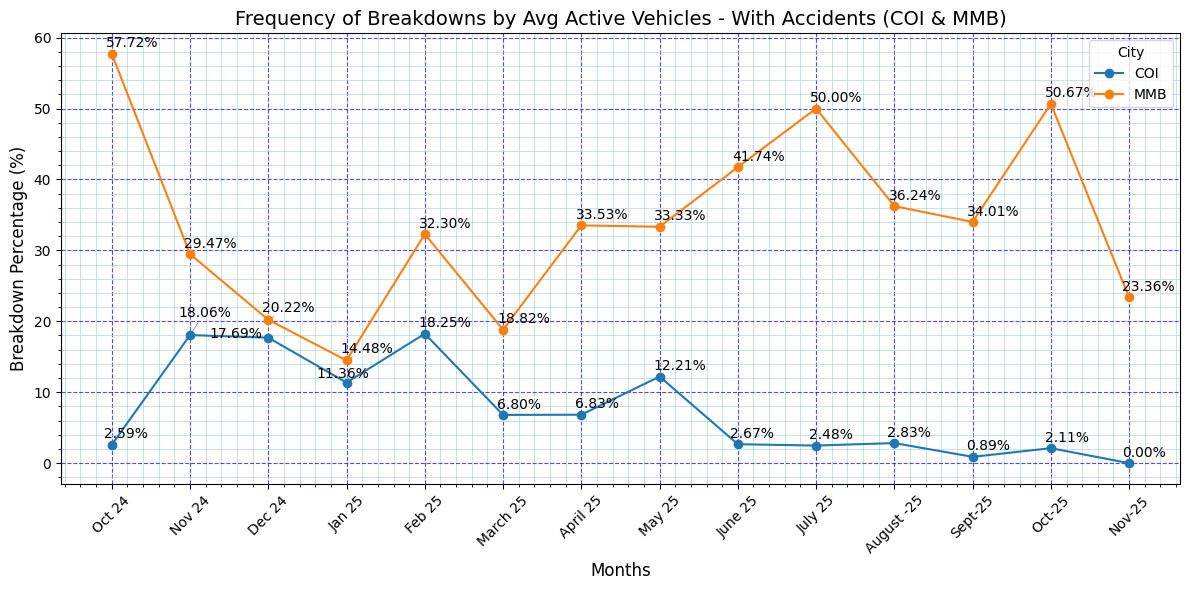

In [ ]:
#Filter for COI and MMB

# Filter the DataFrame to include only 'COI' and 'MMB'
df_coi_mmb = df[['Months', 'COI', 'MMB']]

# Line plot
plt.figure(figsize=(12, 6))
for city in df_coi_mmb.columns[1:]:  # Skip 'Months'
    plt.plot(df_coi_mmb['Months'], df_coi_mmb[city], label=city, marker='o')

# Collect all text annotations
texts = []
for city in df_coi_mmb.columns[1:]:
    for x, y in zip(df_coi_mmb['Months'], df_coi_mmb[city]):
        texts.append(plt.text(x, y + 0.02, f'{y:.2f}%', ha='center', va='bottom', fontsize=10))

# Adjust text to prevent overlap
adjust_text(texts, only_move={'points': 'y', 'text': 'y'}, arrowprops=dict(arrowstyle='->', color='gray', lw=0.5))

# Plot settings
plt.xlabel('Months', fontsize=12)
plt.ylabel('Breakdown Percentage (%)', fontsize=12)
plt.title('Frequency of Breakdowns by Avg Active Vehicles - With Accidents (COI & MMB)', fontsize=14)
plt.xticks(rotation=45)
plt.legend(title='City', loc="upper right")
plt.grid(True, linestyle='--', alpha=0.7, color='blue')
plt.minorticks_on()
plt.grid(which='minor', linestyle='-', linewidth=0.5, color='lightblue')
plt.tight_layout()

# Show plot
plt.show()


### Without Accidents

In [ ]:

import io
import pandas as pd
pd.read_csv(io.StringIO('''
Year,Months,BLR,CHN,COI,HYD,MMB
2024,Apr 24,11.39%,68.22%,14.52%,18.78%,79.50%
2024,May 24,21.68%,63.85%,4.92%,15.03%,32.63%
2024,June 24,20.78%,52.48%,0.00%,15.56%,19.23%
2024,Jul 24,30.99%,37.66%,1.10%,29.87%,65.45%
2024,Aug 24,44.21%,30.11%,2.33%,19.10%,69.51%
2024,Sep 24,34.65%,20.35%,3.19%,13.09%,46.97%
2024,Oct 24,43.47%,30.47%,1.72%,16.02%,53.30%
2024,Nov 24,28.19%,26.19%,13.35%,9.00%,26.41%
2024,Dec 24,22.37%,28.44%,11.54%,13.66%,17.71%
2025,Jan 25,22.54%,16.37%,8.33%,11.27%,12.30%
2025,Feb 25,16.17%,28.98%,13.87%,12.25%,27.25%
2025,March 25,22.46%,21.34%,2.72%,17.54%,17.98%
2025,April 25,20.57%,31.30%,4.35%,11.45%,31.16%
2025,May 25,26.90%,13.26%,8.72%,8.62%,29.09%
2025,June 25,24.36%,17.28%,0.53%,5.42%,40.24%
2025,July 25,19.75%,18.15%,1.49%,18.88%,45.91%
2025,August -25,15.09%,28.66%,0.47%,9.26%,34.56%
2025,Sept -25,10.48%,34.78%,0.00%,17.41%,32.31%
2025,Oct-25,6.51%,12.03%,0.00%,22.28%,49.33%
2025,Nov-25,4.02%,8.38%,0.00%,5.50%,21.05%
'''), header=None)


,0,1,2,3,4,5,6
0,Year,Months,BLR,CHN,COI,HYD,MMB
1,2024,Apr 24,11.39%,68.22%,14.52%,18.78%,79.50%
2,2024,May 24,21.68%,63.85%,4.92%,15.03%,32.63%
3,2024,June 24,20.78%,52.48%,0.00%,15.56%,19.23%
4,2024,Jul 24,30.99%,37.66%,1.10%,29.87%,65.45%
5,2024,Aug 24,44.21%,30.11%,2.33%,19.10%,69.51%
6,2024,Sep 24,34.65%,20.35%,3.19%,13.09%,46.97%
7,2024,Oct 24,43.47%,30.47%,1.72%,16.02%,53.30%
8,2024,Nov 24,28.19%,26.19%,13.35%,9.00%,26.41%
9,2024,Dec 24,22.37%,28.44%,11.54%,13.66%,17.71%


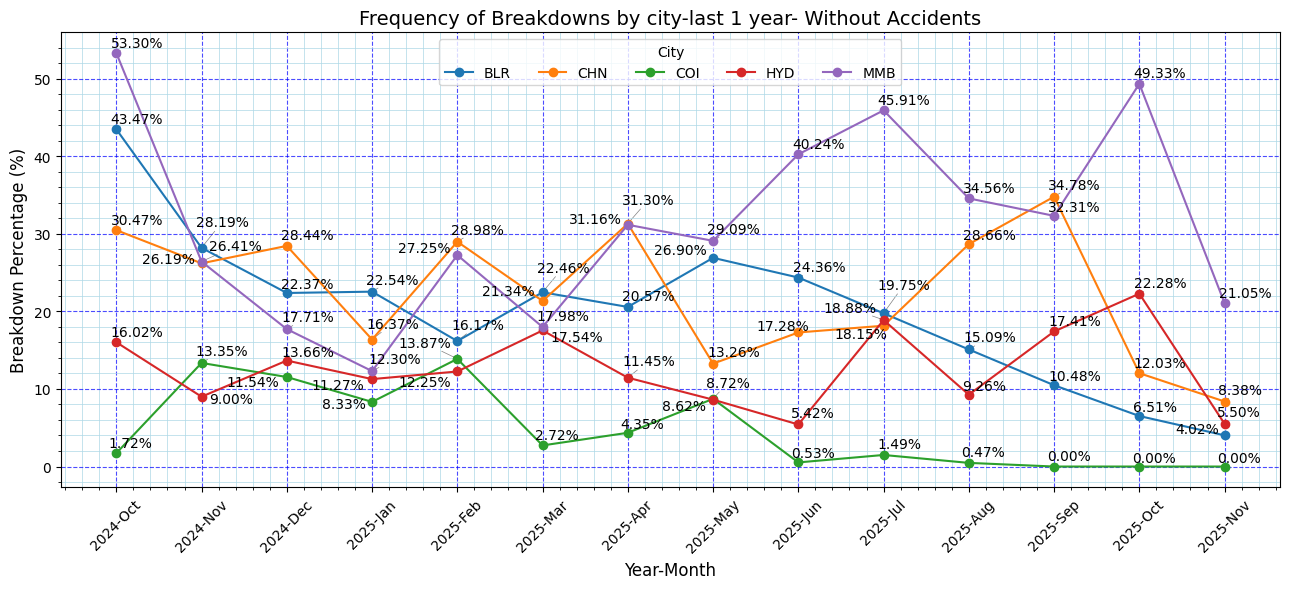

In [ ]:
import pandas as pd
import io
import matplotlib.pyplot as plt
from adjustText import adjust_text

# Data with percentage values (without accidents)
data1 = '''
Year,Months,BLR,CHN,COI,HYD,MMB
2024,Oct 24,43.47%,30.47%,1.72%,16.02%,53.30%
2024,Nov 24,28.19%,26.19%,13.35%,9.00%,26.41%
2024,Dec 24,22.37%,28.44%,11.54%,13.66%,17.71%
2025,Jan 25,22.54%,16.37%,8.33%,11.27%,12.30%
2025,Feb 25,16.17%,28.98%,13.87%,12.25%,27.25%
2025,March 25,22.46%,21.34%,2.72%,17.54%,17.98%
2025,April 25,20.57%,31.30%,4.35%,11.45%,31.16%
2025,May 25,26.90%,13.26%,8.72%,8.62%,29.09%
2025,June 25,24.36%,17.28%,0.53%,5.42%,40.24%
2025,July 25,19.75%,18.15%,1.49%,18.88%,45.91%
2025,August -25,15.09%,28.66%,0.47%,9.26%,34.56%
2025,Sept -25,10.48%,34.78%,0.00%,17.41%,32.31%
2025,Oct-25,6.51%,12.03%,0.00%,22.28%,49.33%
2025,Nov-25,4.02%,8.38%,0.00%,5.50%,21.05%
'''

# Read the data
df = pd.read_csv(io.StringIO(data1), dtype=str)

# Convert percentage strings to float
for col in df.columns[2:]:
    df[col] = df[col].str.rstrip('%').astype(float)

# Extract year from the 'Months' column if it exists, otherwise assume a dummy year for conversion
# If 'Year' column is present, use it directly
if 'Year' in df.columns:
    df['Year_Str'] = df['Year'].astype(str)
else:
    # Extract year from Months (assuming format like 'Mon YY' or 'Month YY')
    df['Year_Str'] = '20' + df['Months'].str.extract(r'(\d{2})$')[0]


# Use 'mixed' format to handle both full and abbreviated month names and combine with extracted/provided year
df['Date'] = pd.to_datetime(df['Year_Str'] + '-' + df['Months'], format='mixed', errors='coerce')

# Drop rows where Date conversion failed
df.dropna(subset=['Date'], inplace=True)


# Sort by date
df = df.sort_values('Date')

# Create x-axis labels like '2024-Apr'
df['Label'] = df['Date'].dt.strftime('%Y-%b')

# Plotting
plt.figure(figsize=(13, 6))
for city in df.columns[2:7]:
    plt.plot(df['Label'], df[city], label=city, marker='o')

# Add value labels
texts = []
for city in df.columns[2:7]:
    for x, y in zip(df['Label'], df[city]):
        texts.append(plt.text(x, y + 0.02, f'{y:.2f}%', ha='center', va='bottom', fontsize=10))

adjust_text(texts, only_move={'points': 'y', 'text': 'y'}, arrowprops=dict(arrowstyle='->', color='gray', lw=0.5))

# Customize chart
plt.xlabel('Year-Month', fontsize=12)
plt.ylabel('Breakdown Percentage (%)', fontsize=12)
plt.title('Frequency of Breakdowns by city-last 1 year- Without Accidents', fontsize=14)
plt.xticks(rotation=45)
plt.legend(title='City', loc="upper center", ncol=len(df.columns[2:7]))
plt.grid(True, linestyle='--', alpha=0.7, color='blue')
plt.minorticks_on()
plt.grid(which='minor', linestyle='-', linewidth=0.5, color='lightblue')
plt.tight_layout()
plt.show()

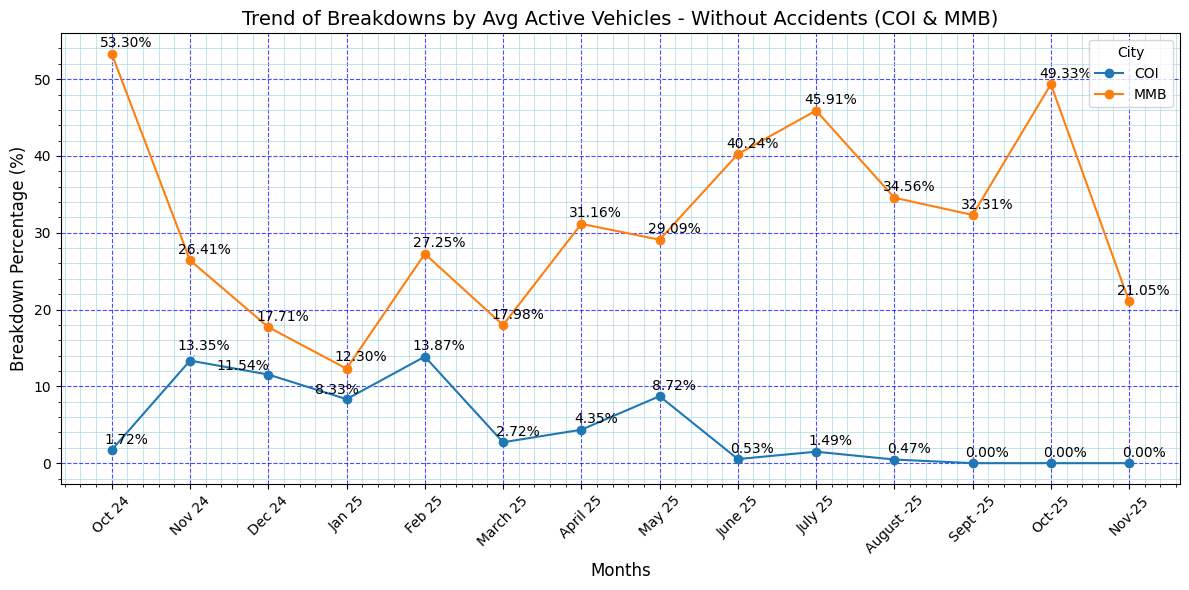

In [ ]:
#graph just for COI and MMB

import matplotlib.pyplot as plt
# Assuming 'df' DataFrame is already loaded and processed as in the previous code.

# Filter the DataFrame to include only 'COI' and 'MMB' (without accidents)
df_coi_mmb = df[['Months', 'COI', 'MMB']]

# Line plot
plt.figure(figsize=(12, 6))
for city in df_coi_mmb.columns[1:]:  # Skip 'Months'
    plt.plot(df_coi_mmb['Months'], df_coi_mmb[city], label=city, marker='o')

# Collect all text annotations
texts = []
for city in df_coi_mmb.columns[1:]:
    for x, y in zip(df_coi_mmb['Months'], df_coi_mmb[city]):
        texts.append(plt.text(x, y + 0.02, f'{y:.2f}%', ha='center', va='bottom', fontsize=10))

# Adjust text to prevent overlap
adjust_text(texts, only_move={'points': 'y', 'text': 'y'}, arrowprops=dict(arrowstyle='->', color='gray', lw=0.5))

# Plot settings
plt.xlabel('Months', fontsize=12)
plt.ylabel('Breakdown Percentage (%)', fontsize=12)
plt.title('Trend of Breakdowns by Avg Active Vehicles - Without Accidents (COI & MMB)', fontsize=14)
plt.xticks(rotation=45)
plt.legend(title='City', loc="upper right")
plt.grid(True, linestyle='--', alpha=0.7, color='blue')
plt.minorticks_on()
plt.grid(which='minor', linestyle='-', linewidth=0.5, color='lightblue')
plt.tight_layout()

# Show plot
plt.show()


### Rate of breakdowns

In [ ]:

import io
import pandas as pd
pd.read_csv(io.StringIO('''
Year,Months,BLR,CHN,COI,HYD,MMB
2024,May 24,1.65%,2.17%,4.76%,2.50%,4.67%
2024,June 24,0.82%,1.32%,0.00%,1.06%,2.82%
2024,July 24,2.02%,6.74%,3.53%,4.79%,14.37%
2024,Aug 24,2.34%,2.29%,2.15%,1.55%,10.96%
2024,Sep 24,5.96%,3.30%,0.97%,4.15%,6.55%
2024,Oct 24,2.61%,2.82%,0.82%,4.35%,6.45%
2024,Nov 24,5.16%,2.74%,4.62%,4.85%,1.88%
2024,Dec 24,1.92%,2.25%,1.52%,0.97%,1.34%
2025,Jan 25,2.19%,1.24%,1.44%,0.49%,2.42%
2025,Feb 25,2.19%,2.79%,3.57%,1.43%,5.11%
2025,March 25,3.45%,3.20%,3.11%,2.55%,4.57%
2025,April 25,5.96%,8.90%,1.18%,2.97%,10.22%
2025,May 25,1.94%,1.98%,2.76%,2.45%,11.02%
2025,June 25,5.39%,4.86%,2.06%,0.82%,11.44%
2025,July 25,8.93%,2.43%,0.00%,6.17%,18.62%
2025,Aug 25,4.79%,6.99%,0.00%,5.02%,25.99%
2025,Sept-25,5.36%,6.46%,0.00%,10.60%,18.09%
2025,Oct-25,3.85%,2.72%,0.00%,8.64%,16.22%
2025,Nov-25,6.36%,5.76%,0.00%,9.55%,19.95%
'''), header=None)


,0,1,2,3,4,5,6
0,Year,Months,BLR,CHN,COI,HYD,MMB
1,2024,May 24,1.65%,2.17%,4.76%,2.50%,4.67%
2,2024,June 24,0.82%,1.32%,0.00%,1.06%,2.82%
3,2024,July 24,2.02%,6.74%,3.53%,4.79%,14.37%
4,2024,Aug 24,2.34%,2.29%,2.15%,1.55%,10.96%
5,2024,Sep 24,5.96%,3.30%,0.97%,4.15%,6.55%
6,2024,Oct 24,2.61%,2.82%,0.82%,4.35%,6.45%
7,2024,Nov 24,5.16%,2.74%,4.62%,4.85%,1.88%
8,2024,Dec 24,1.92%,2.25%,1.52%,0.97%,1.34%
9,2025,Jan 25,2.19%,1.24%,1.44%,0.49%,2.42%


In [ ]:
rate_of_breakdowns=pd.read_csv(io.StringIO('''
Year,Months,BLR,CHN,COI,HYD,MMB
2024,May 24,1.65%,2.17%,4.76%,2.50%,4.67%
2024,June 24,0.82%,1.32%,0.00%,1.06%,2.82%
2024,July 24,2.02%,6.74%,3.53%,4.79%,14.37%
2024,Aug 24,2.34%,2.29%,2.15%,1.55%,10.96%
2024,Sep 24,5.96%,3.30%,0.97%,4.15%,6.55%
2024,Oct 24,2.61%,2.82%,0.82%,4.35%,6.45%
2024,Nov 24,5.16%,2.74%,4.62%,4.85%,1.88%
2024,Dec 24,1.92%,2.25%,1.52%,0.97%,1.34%
2025,Jan 25,2.19%,1.24%,1.44%,0.49%,2.42%
2025,Feb 25,2.19%,2.79%,3.57%,1.43%,5.11%
2025,March 25,3.45%,3.20%,3.11%,2.55%,4.57%
2025,April 25,5.96%,8.90%,1.18%,2.97%,10.22%
2025,May 25,1.94%,1.98%,2.76%,2.45%,11.02%
2025,June 25,5.39%,4.86%,2.06%,0.82%,11.44%
2025,July 25,8.93%,2.43%,0.00%,6.17%,18.62%
2025,Aug 25,4.79%,6.99%,0.00%,5.02%,25.99%
2025,Sept-25,5.36%,6.46%,0.00%,10.60%,18.09%
2025,Oct-25,3.85%,2.72%,0.00%,8.64%,16.22%
2025,Nov-25,6.36%,5.76%,0.00%,9.55%,19.95%
'''), header=None)

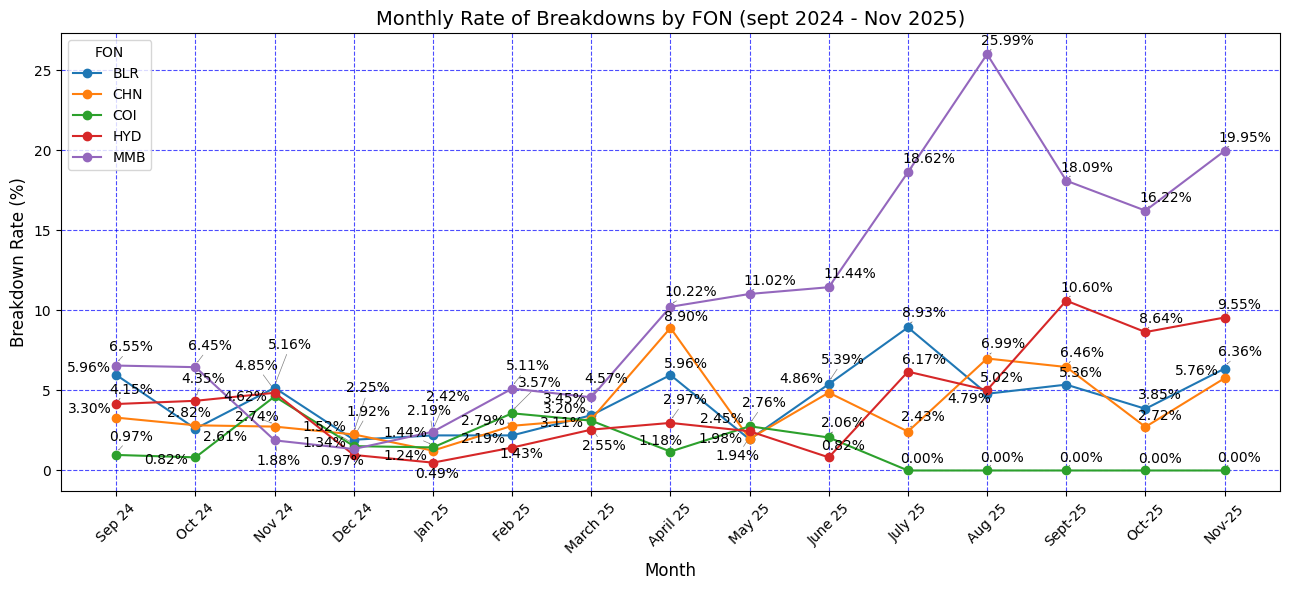

In [ ]:
import pandas as pd
from adjustText import adjust_text

import matplotlib.pyplot as plt

# Prepare the DataFrame
df = rate_of_breakdowns.copy()
df.columns = df.iloc[0]
df = df.drop(0).reset_index(drop=True)

# Filter for last 1 year (Aug-24 to Aug-25)
month_order = [
    'Sep 24', 'Oct 24', 'Nov 24', 'Dec 24',
    'Jan 25', 'Feb 25', 'March 25', 'April 25', 'May 25',
    'June 25', 'July 25', 'Aug 25', 'Sept-25','Oct-25','Nov-25'
]
df = df[df['Months'].isin(month_order)].copy()
df['Months'] = pd.Categorical(df['Months'], categories=month_order, ordered=True)
df = df.sort_values('Months')

# Convert percentage strings to float
cities = ['BLR', 'CHN', 'COI', 'HYD', 'MMB']
for city in cities:
    df[city] = df[city].str.rstrip('%').astype(float)

# Plot
plt.figure(figsize=(13, 6))
texts = []
for city in cities:
    plt.plot(df['Months'], df[city], marker='o', label=city)
    for x, y in zip(df['Months'], df[city]):
        texts.append(plt.text(x, y + 0.15, f'{y:.2f}%', ha='center', va='bottom', fontsize=10))

adjust_text(texts, only_move={'points': 'y', 'text': 'y'}, arrowprops=dict(arrowstyle='->', color='gray', lw=0.5))

plt.xlabel('Month', fontsize=12)
plt.ylabel('Breakdown Rate (%)', fontsize=12)
plt.title('Monthly Rate of Breakdowns by FON (sept 2024 - Nov 2025)', fontsize=14)
plt.xticks(rotation=45)
plt.legend(title='FON')
plt.grid(True, linestyle='--', alpha=0.7, color='blue')
plt.tight_layout()
plt.show()

In [ ]:
!pip install adjustText

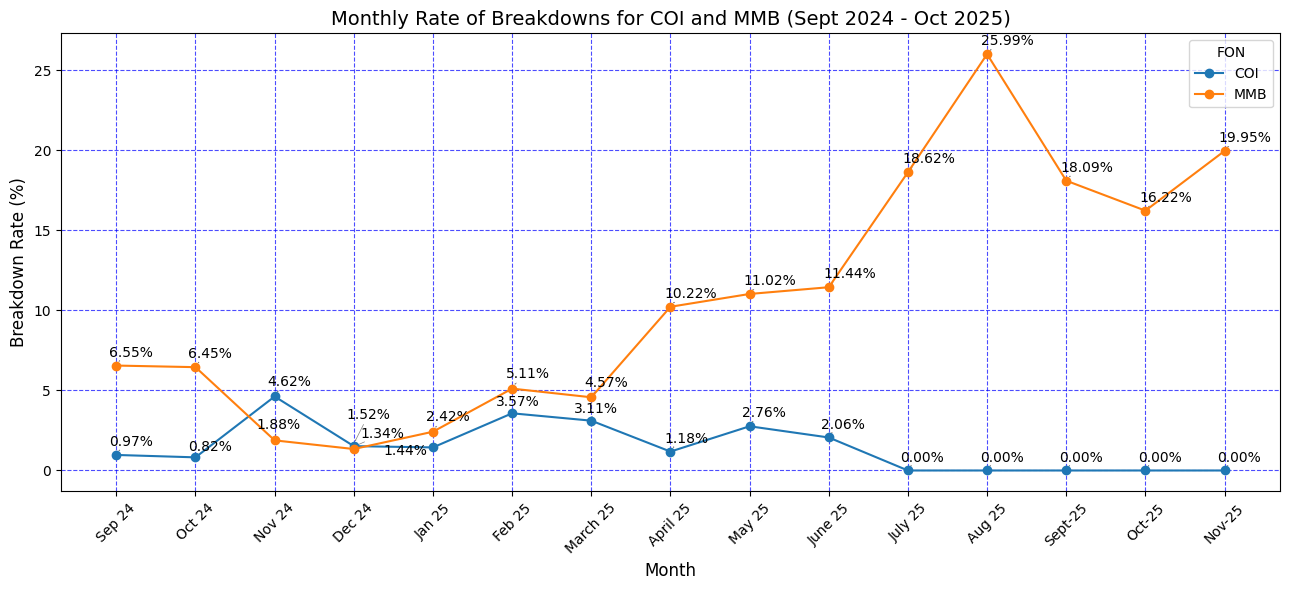

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from adjustText import adjust_text

# Prepare the DataFrame
df = rate_of_breakdowns.copy()
df.columns = df.iloc[0]
df = df.drop(0).reset_index(drop=True)

# Filter for last 1 year
month_order = [
    'Sep 24', 'Oct 24', 'Nov 24', 'Dec 24',
    'Jan 25', 'Feb 25', 'March 25', 'April 25', 'May 25',
    'June 25', 'July 25', 'Aug 25', 'Sept-25', 'Oct-25','Nov-25'
]
df = df[df['Months'].isin(month_order)].copy()
df['Months'] = pd.Categorical(df['Months'], categories=month_order, ordered=True)
df = df.sort_values('Months')

# Convert percentage strings to float
cities = ['COI', 'MMB']
for city in cities:
    df[city] = df[city].str.rstrip('%').astype(float)

# Plot
plt.figure(figsize=(13, 6))
texts = []
for city in cities:
    plt.plot(df['Months'], df[city], marker='o', label=city)
    for x, y in zip(df['Months'], df[city]):
        texts.append(plt.text(x, y + 0.15, f'{y:.2f}%', ha='center', va='bottom', fontsize=10))

adjust_text(texts, only_move={'points': 'y', 'text': 'y'}, arrowprops=dict(arrowstyle='->', color='gray', lw=0.5))

plt.xlabel('Month', fontsize=12)
plt.ylabel('Breakdown Rate (%)', fontsize=12)
plt.title('Monthly Rate of Breakdowns for COI and MMB (Sept 2024 - Oct 2025)', fontsize=14)
plt.xticks(rotation=45)
plt.legend(title='FON')
plt.grid(True, linestyle='--', alpha=0.7, color='blue')
plt.tight_layout()
plt.show()

In [ ]:
import io
import pandas as pd
rate_of_breakdowns_total=pd.read_csv(io.StringIO('''
Year,Months,Total
2024,May 24,4.02%
2024,June 24,1.54%
2024,July 24,7.50%
2024,Aug 24,5.03%
2024,Sep 24,4.89%
2024,Oct 24,4.12%
2024,Nov 24,3.42%
2024,Dec 24,1.56%
2025,Jan 25,1.64%
2025,Feb 25,3.33%
2025,March 25,3.52%
2025,April 25,6.69%
2025,May 25,4.86%
2025,June 25,5.64%
2025,July 25,8.15%
2025,Aug 25,10.73%
2025,Sept-25,8.94%
2025,Oct-25,6.89%
2025,Nov-25,8.93%
'''), header=None)


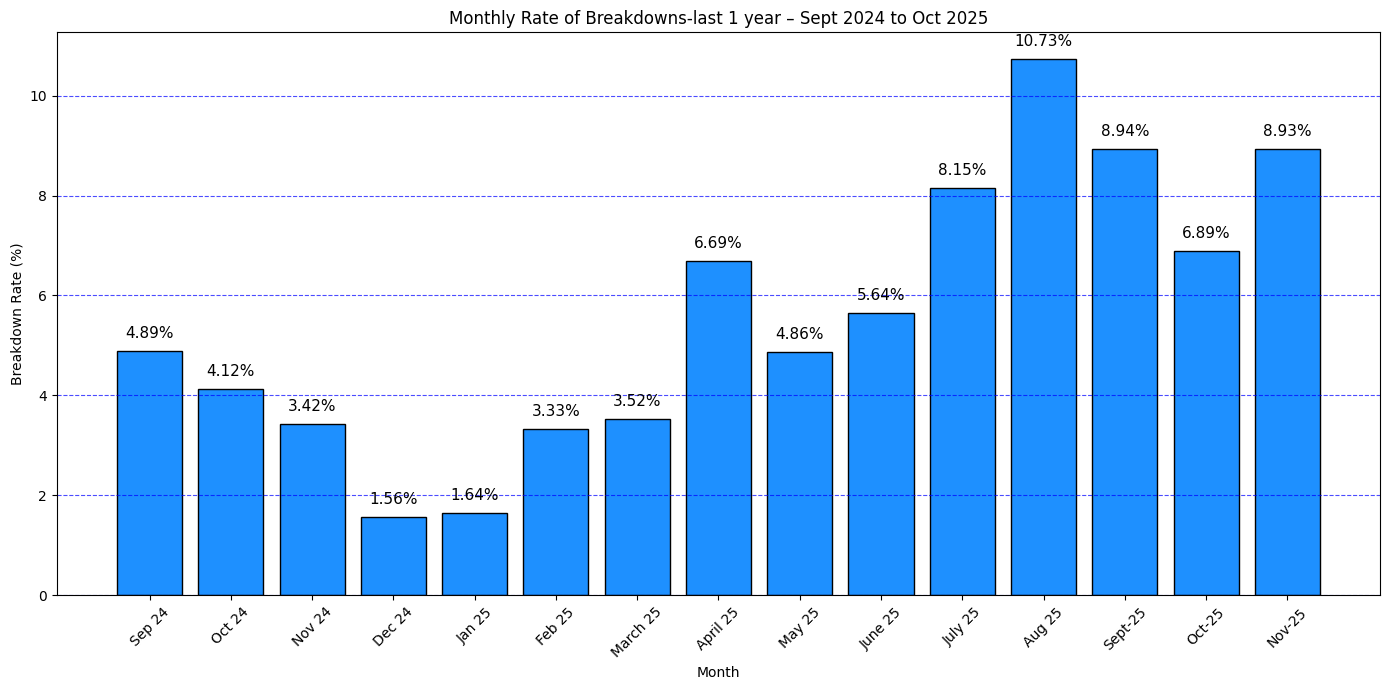

In [ ]:
import matplotlib.pyplot as plt

# Prepare the DataFrame
df_total = rate_of_breakdowns_total.copy()
df_total.columns = df_total.iloc[0]
df_total = df_total.drop(0).reset_index(drop=True)

# Filter for Aug 24 to Aug 25
month_order = [
   'Sep 24', 'Oct 24', 'Nov 24', 'Dec 24',
    'Jan 25', 'Feb 25', 'March 25', 'April 25', 'May 25',
    'June 25', 'July 25', 'Aug 25', 'Sept-25', 'Oct-25','Nov-25'
]
df_total = df_total[df_total['Months'].isin(month_order)].copy()
df_total['Months'] = pd.Categorical(df_total['Months'], categories=month_order, ordered=True)
df_total = df_total.sort_values('Months')

# Convert percentage strings to float
df_total['Total'] = df_total['Total'].str.rstrip('%').astype(float)

# Plot
plt.figure(figsize=(14, 7))
bars = plt.bar(df_total['Months'], df_total['Total'], color='dodgerblue', edgecolor='black')

# Add data labels
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.2, f'{yval:.2f}%', ha='center', va='bottom', fontsize=11)

plt.xlabel('Month')
plt.ylabel('Breakdown Rate (%)')
plt.title('Monthly Rate of Breakdowns-last 1 year – Sept 2024 to Oct 2025')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7, color='blue')
plt.tight_layout()
plt.show()

## Breakdown trend in last 30 days

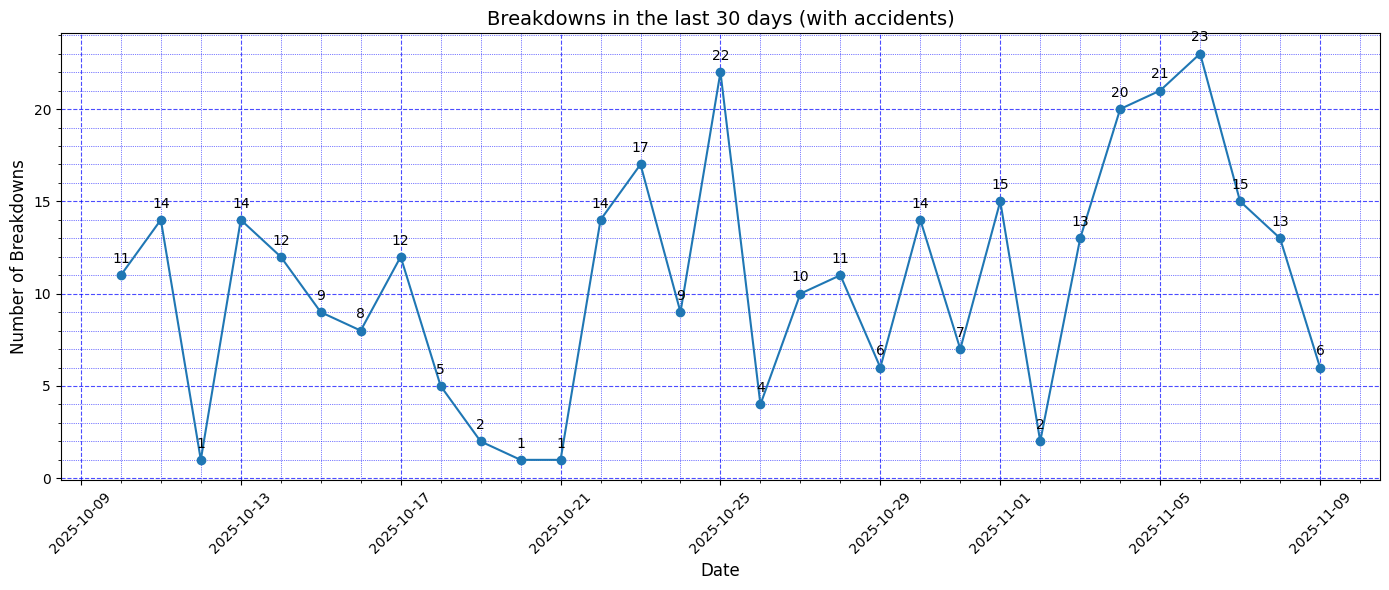

In [ ]:

from datetime import datetime, timedelta

# Assuming 'data' DataFrame is available as in the original code

def plot_breakdowns_last_30_days(data, with_accidents=True):
    end_date = datetime(2025, 11, 9)  # Fixed end date
    start_date = end_date - timedelta(days=30)

    filtered_data = data[(data['Incident Date'] >= start_date) & (data['Incident Date'] <= end_date)]

    if not with_accidents:
        filtered_data = filtered_data[filtered_data['Incident Type'] != 'Accident']

    daily_breakdowns = filtered_data.groupby('Incident Date')['ID'].count()
    all_dates = pd.date_range(start=start_date, end=end_date)
    daily_breakdowns = daily_breakdowns.reindex(all_dates, fill_value=0)

    plt.figure(figsize=(14, 6))
    plt.plot(daily_breakdowns.index, daily_breakdowns.values, marker='o')

    for x, y in zip(daily_breakdowns.index, daily_breakdowns.values):
        plt.text(x, y + 0.5, y, ha='center', va='bottom', fontsize=10)

    plt.xlabel('Date', fontsize=12)
    plt.ylabel('Number of Breakdowns', fontsize=12)
    title = 'Breakdowns in the last 30 days'
    if with_accidents:
        title += ' (with accidents)'
    else:
        title += ' (without accidents)'
    plt.title(title, fontsize=14)
    plt.xticks(rotation=45)
    plt.tight_layout()
# Major gridlines (dashed blue)
    plt.grid(True, linestyle='--', alpha=0.7, color='blue')

# Minor gridlines (finer, lighter blue)
    plt.minorticks_on()
    plt.grid(which='minor', linestyle=':', linewidth=0.5, color='blue')

    plt.show()


# Example usage (assuming 'data' DataFrame is available):
plot_breakdowns_last_30_days(data, with_accidents=True)


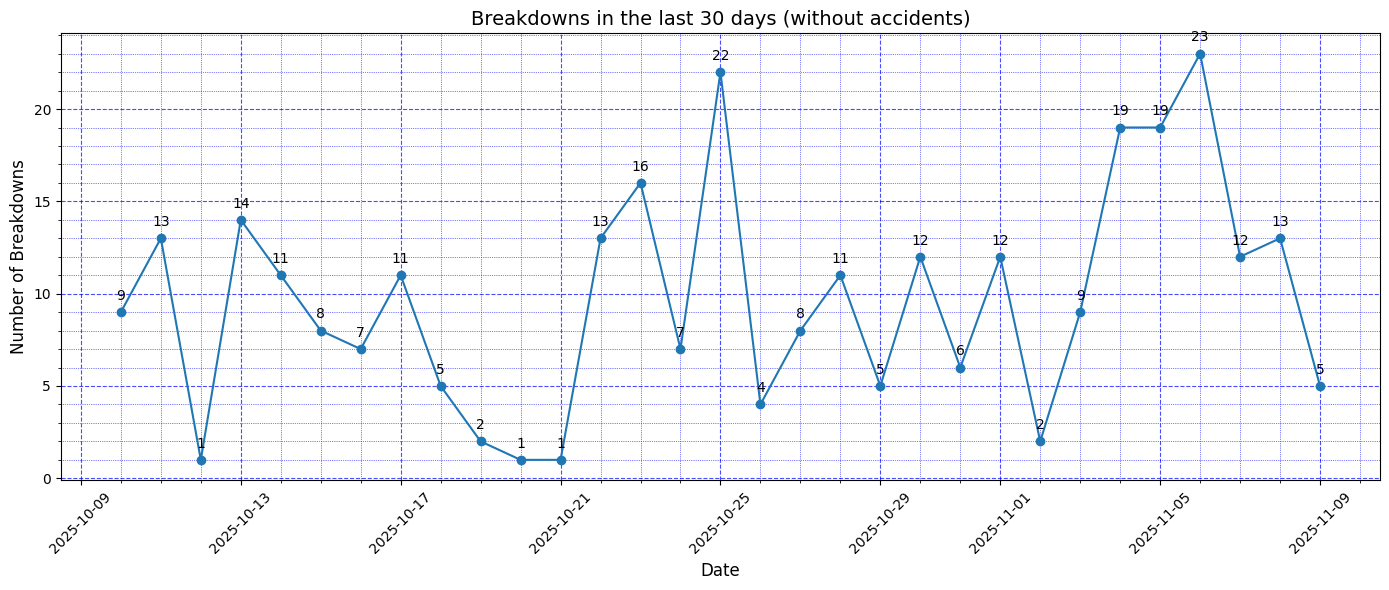

In [ ]:
plot_breakdowns_last_30_days(data, with_accidents=False)


## Breakdown trend for last 90 days

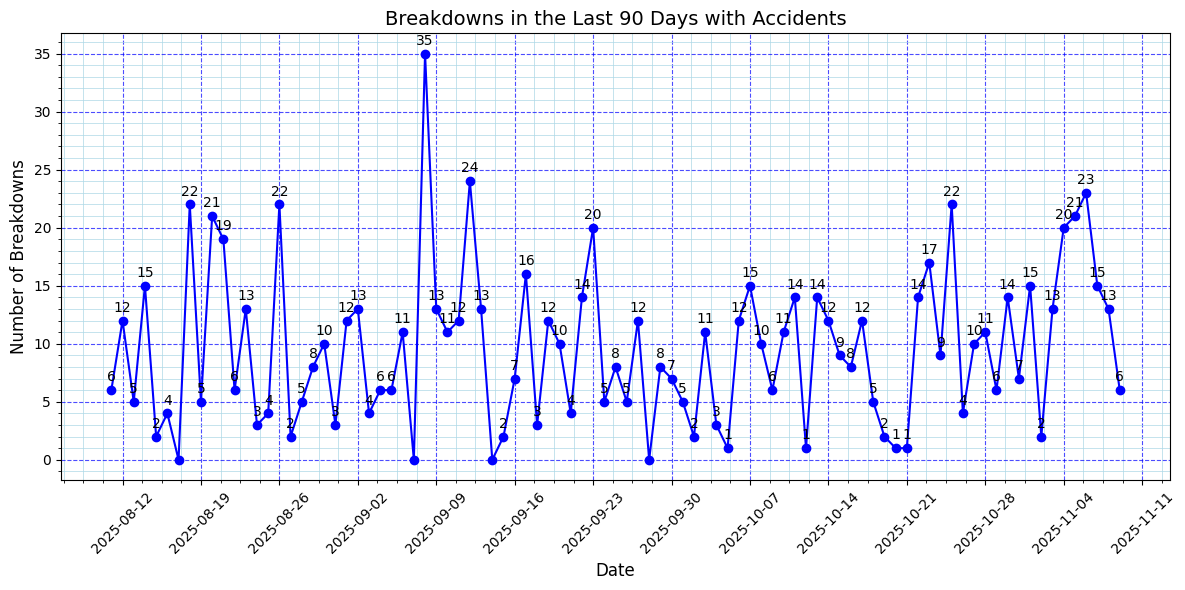

In [ ]:

import matplotlib.dates as mdates
from datetime import datetime

# Define end_date (or use `datetime.today()` for dynamic calculation)
end_date = datetime(2025, 11, 9)  # Replace with `datetime.today()` if needed

# Ensure 'Incident Date' is in datetime format
data['Incident Date'] = pd.to_datetime(data['Incident Date'])

# Filter data for the last 90 days from 2nd March
start_date = end_date - pd.DateOffset(days=90)
last_90_days_data = data[(data['Incident Date'] >= start_date) & (data['Incident Date'] <= end_date)]

# Group data by date and count breakdowns
daily_breakdowns = last_90_days_data.groupby('Incident Date')['ID'].count()

# Reindex to include all dates in the range, filling missing dates with zero
all_dates = pd.date_range(start=start_date, end=end_date)
daily_breakdowns = daily_breakdowns.reindex(all_dates, fill_value=0)

# Create a line plot
plt.figure(figsize=(12, 6))
plt.plot(daily_breakdowns.index, daily_breakdowns.values, marker='o', linestyle='-', color='blue')

# Add data labels dynamically
for x, y in zip(daily_breakdowns.index, daily_breakdowns.values):
    if y > 0:  # Show labels only for non-zero values
        plt.text(x, y + 0.5, str(y), ha='center', va='bottom', fontsize=10)

# Customize the chart
plt.xlabel('Date', fontsize=12)
plt.ylabel('Number of Breakdowns', fontsize=12)
plt.title('Breakdowns in the Last 90 Days with Accidents', fontsize=14)
plt.xticks(rotation=45)

# Format x-axis
plt.gca().xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))  # Major ticks on weekly intervals
plt.gca().xaxis.set_minor_locator(mdates.DayLocator())  # Minor ticks on daily intervals

# Major gridlines (dashed blue)
plt.grid(True, linestyle='--', alpha=0.7, color='blue')

# Minor gridlines (finer, lighter blue)
plt.minorticks_on()
plt.grid(which='minor', linestyle='-', linewidth=0.5, color='lightblue')

# Show the plot
plt.tight_layout()
plt.show()


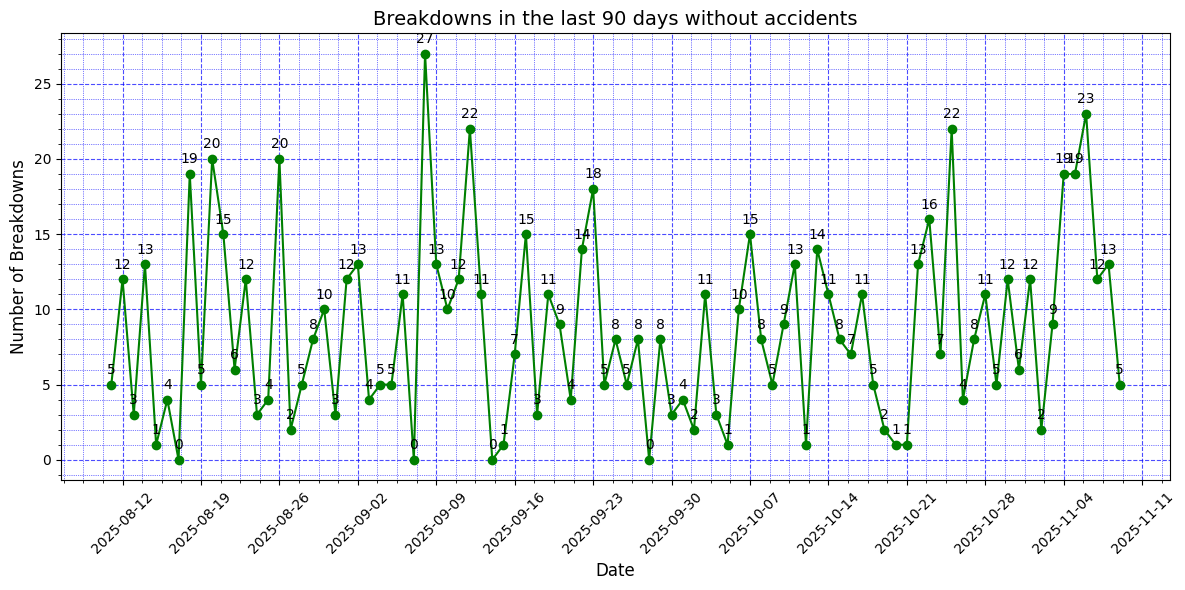

In [ ]:
#  Breakdowns for last 90 days , without accidents.


# Filter data for the last 90 days
start_date = end_date - pd.DateOffset(days=90)
last_90_days_data = data[(data['Incident Date'] >= start_date) & (data['Incident Date'] <= end_date)]

# Filter out rows with 'Incident Type' as 'Accident'
last_90_days_data_no_accidents = last_90_days_data[last_90_days_data['Incident Type'] != 'Accident']

# Group data by date and count breakdowns
daily_breakdowns_no_accidents = last_90_days_data_no_accidents.groupby('Incident Date')['ID'].count()

# Reindex to include all dates in the range, filling missing dates with zero
all_dates = pd.date_range(start=start_date, end=end_date)
daily_breakdowns_no_accidents = daily_breakdowns_no_accidents.reindex(all_dates, fill_value=0)


# Create a line plot
plt.figure(figsize=(12, 6))
plt.plot(daily_breakdowns_no_accidents.index, daily_breakdowns_no_accidents.values, marker='o',color='green')

# Add data labels
for x, y in zip(daily_breakdowns_no_accidents.index, daily_breakdowns_no_accidents.values):
    plt.text(x, y + 0.5, y, ha='center', va='bottom', fontsize=10)

# Customize the chart
plt.xlabel('Date', fontsize=12)
plt.ylabel('Number of Breakdowns', fontsize=12)
plt.title('Breakdowns in the last 90 days without accidents', fontsize=14)
plt.xticks(rotation=45)
plt.gca().xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))  # Major ticks on weekly intervals
plt.gca().xaxis.set_minor_locator(mdates.DayLocator())  # Minor ticks on daily intervals
plt.tight_layout()

# Major gridlines (dashed blue)
plt.grid(True, linestyle='--', alpha=0.7, color='blue')

# Minor gridlines (finer, lighter blue)
plt.minorticks_on()
plt.grid(which='minor', linestyle=':', linewidth=0.5, color='blue')

# Show the plot
plt.show()


## Accidents in last 1 year

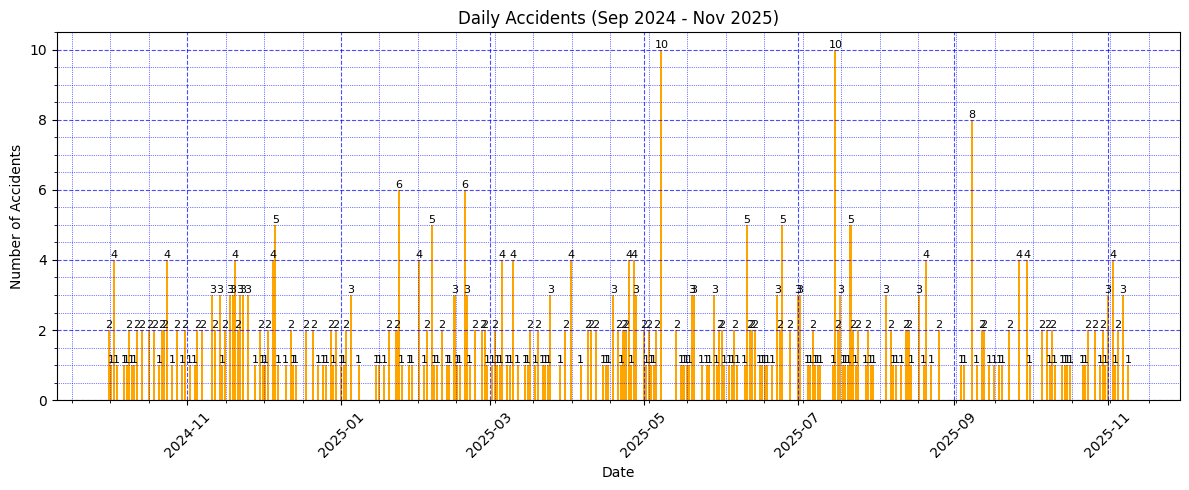

In [ ]:
# Filter data from sep 24 to Nov 25
start_date = '2024-09-01'
end_date = '2025-11-30'
filtered_data = data[(data['Incident Date'] >= start_date) & (data['Incident Date'] <= end_date)]

# Filter for accidents only
accident_data = filtered_data[filtered_data['Incident Type'] == 'Accident']

# Group by date and count accidents
daily_accidents = accident_data.groupby('Incident Date')['ID'].count()

# Create a histogram (bar plot) of daily accidents
plt.figure(figsize=(12, 5))
plt.bar(daily_accidents.index, daily_accidents.values, color='orange')

# Add data labels to the bars
for x, y in zip(daily_accidents.index, daily_accidents.values):
    plt.text(x, y, str(y), ha='center', va='bottom', fontsize=8)

plt.xlabel('Date')
plt.ylabel('Number of Accidents')
plt.title('Daily Accidents (Sep 2024 - Nov 2025)')
plt.grid(True, linestyle='--', alpha=0.7, color='blue')

# Add minor gridlines
plt.minorticks_on()
plt.grid(which='minor', linestyle=':', linewidth=0.5, color='blue')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


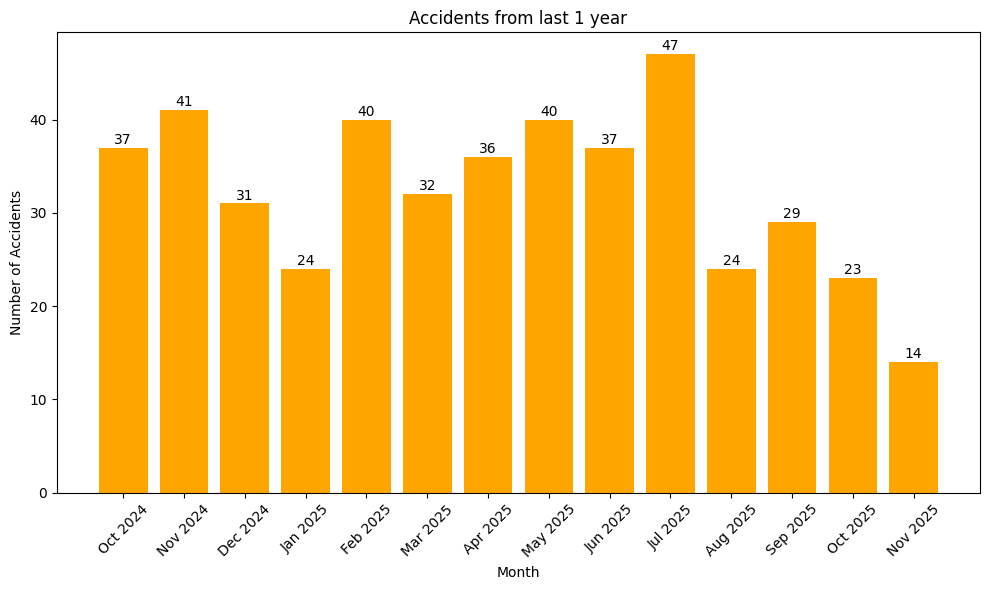

In [ ]:


# Filter data for accidents within the specified date range
accident_data_filtered = accident_data[(accident_data['Incident Date'] >= '2024-09-01') & (accident_data['Incident Date'] <= '2025-11-30')]

# Group by month and count accidents
monthly_accidents = accident_data_filtered.groupby(accident_data_filtered['Incident Date'].dt.to_period('M'))['ID'].count()

# Convert the index to datetime objects for plotting
monthly_accidents.index = monthly_accidents.index.to_timestamp()

# Create the bar plot
plt.figure(figsize=(10, 6))
bars = plt.bar(monthly_accidents.index.strftime('%b %Y'), monthly_accidents.values, color='orange')

# Add data labels on top of each bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.1, yval, ha='center', va='bottom')

plt.xlabel('Month')
plt.ylabel('Number of Accidents')
plt.title('Accidents from last 1 year')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Active vehicle months available: ['Apr-2024', 'Apr-2025', 'Aug-2024', 'Aug-2025', 'Dec-2024', 'Feb-2025', 'Jan-2025', 'Jul-2024', 'Jul-2025', 'Jun-2024', 'Jun-2025', 'Mar-2025', 'May-2024', 'May-2025', 'Nov-2024', 'Oct-2024', 'Sep-2024']


/tmp/ipython-input-2099521745.py:81: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  .fillna(method='ffill')  # Fill missing months
/tmp/ipython-input-2099521745.py:81: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  .fillna(method='ffill')  # Fill missing months
/tmp/ipython-input-2099521745.py:81: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  .fillna(method='ffill')  # Fill missing months
/tmp/ipython-input-2099521745.py:81: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  .fillna(method='ffill')  # Fill missing months
/tmp/ipython-input-2099521745.py:81: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future ver

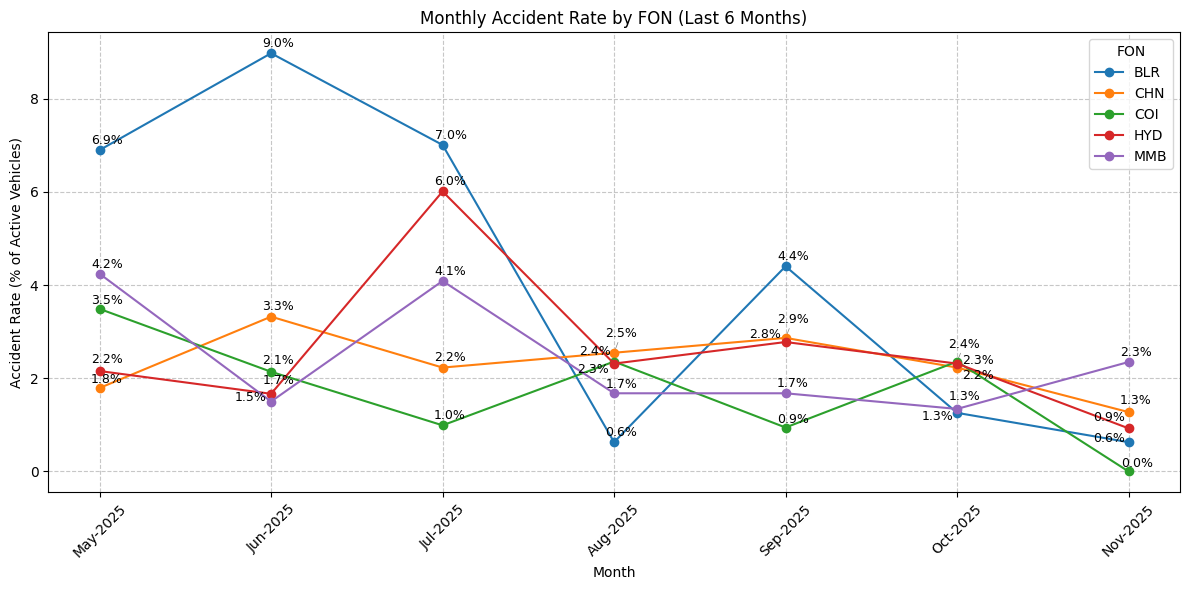

In [ ]:
import matplotlib.pyplot as plt
from adjustText import adjust_text
import pandas as pd

# --- 1) Prepare Active Vehicles DataFrame ---
active_vehicles_long = active_vehicles_data.melt(
    id_vars='FON', var_name='Month', value_name='Active_Vehicles'
)

# Clean whitespace and normalize text
active_vehicles_long['Month'] = (
    active_vehicles_long['Month']
    .str.strip()
    .str.replace(r'\s+', '', regex=True)
    .str.replace('Sept', 'Sep')
    .str.replace('August', 'Aug')
)

month_mapping = {
    'April-24': 'Apr-2024', 'May-24': 'May-2024', 'June-24': 'Jun-2024',
    'July-24': 'Jul-2024', 'Aug-24': 'Aug-2024', 'Sep-24': 'Sep-2024',
    'Oct-24': 'Oct-2024', 'Nov-24': 'Nov-2024', 'Dec-24': 'Dec-2024',
    'Jan-25': 'Jan-2025', 'Feb-25': 'Feb-2025', 'March-25': 'Mar-2025',
    'April-25': 'Apr-2025', 'May-25': 'May-2025', 'June-25': 'Jun-2025',
    'July-25': 'Jul-2025', 'Aug-25': 'Aug-2025', 'Sep-25': 'Sep-2025', 'Oct-25': 'Oct-2025','Nov-25': 'Nov-2025'
}
active_vehicles_long['Month_fmt'] = active_vehicles_long['Month'].map(month_mapping)

active_vehicles_long = active_vehicles_long.drop_duplicates(subset=['FON', 'Month_fmt'])

# --- 2) Prepare Accident Data ---
data['Incident Date'] = pd.to_datetime(data['Incident Date'], errors='coerce')
start_date = '2024-08-01'
end_date = '2025-11-30'

accident_data = data[
    (data['Incident Date'] >= start_date)
    & (data['Incident Date'] <= end_date)
    & (data['Incident Type'].str.strip().str.lower() == 'accident')
]

# Group and count per month + FON
accident_counts = (
    accident_data.groupby([accident_data['Incident Date'].dt.to_period('M'), 'FON'])['ID']
    .count()
    .reset_index()
)
accident_counts['Month'] = accident_counts['Incident Date'].dt.strftime('%b-%Y')

# Pivot: Month x FON (accident counts)
pivot_df = accident_counts.pivot_table(index='Month', columns='FON', values='ID', fill_value=0)

# --- 3) Define Month Order ---
month_order = [
    'Aug-2024', 'Sep-2024', 'Oct-2024', 'Nov-2024', 'Dec-2024',
    'Jan-2025', 'Feb-2025', 'Mar-2025', 'Apr-2025', 'May-2025',
    'Jun-2025', 'Jul-2025', 'Aug-2025', 'Sep-2025', 'Oct-2025','Nov-2025'
]

pivot_df = pivot_df[~pivot_df.index.duplicated(keep='first')]
pivot_df = pivot_df.reindex(month_order)

# Restrict to last 6 months
last_6_months = ['May-2025', 'Jun-2025', 'Jul-2025', 'Aug-2025', 'Sep-2025', 'Oct-2025','Nov-2025']
pivot_df = pivot_df.loc[last_6_months]

# --- 4) Plot Accident Rate (%) ---
plt.figure(figsize=(12, 6))
texts = []

# Debug: print available active months
print("Active vehicle months available:", sorted(active_vehicles_long['Month_fmt'].dropna().unique()))

for fon in pivot_df.columns:
    active_fon = (
        active_vehicles_long[active_vehicles_long['FON'] == fon]
        .set_index('Month_fmt')['Active_Vehicles']
        .astype(float)
        .sort_index()
        .reindex(month_order)
        .fillna(method='ffill')  # Fill missing months
    )

    active_for_plot = active_fon.reindex(pivot_df.index)
    accident_rate = (pivot_df[fon] / active_for_plot.replace(0, pd.NA)) * 100

    # Plot percentage
    plt.plot(pivot_df.index, accident_rate, marker='o', label=fon)

    # Add percentage labels
    for x, y in zip(pivot_df.index, accident_rate):
        if pd.notna(y):
            label = f"{y:.1f}%"
            texts.append(plt.text(x, y, label, ha='center', va='bottom', fontsize=9))

# Adjust text positions to avoid overlap
adjust_text(
    texts,
    only_move={'points': 'y', 'text': 'y'},
    arrowprops=dict(arrowstyle='-', color='grey', lw=0.5)
)

plt.xlabel('Month')
plt.ylabel('Accident Rate (% of Active Vehicles)')
plt.title('Monthly Accident Rate by FON (Last 6 Months)')
plt.xticks(rotation=45)
plt.legend(title='FON')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


## Ad hoc analysis

### top 10 root causes data frame with graph for last two months

,Root cause,Breakdown Count
0,Front fork issue,62
1,Kelly controller issue,38
2,SEG controller issue,37
3,Accidental Damages,36
4,Brake issue,23
...,...,...
96,vehicle not moving,1
97,welding issue,1
98,welding issue,1
99,windshield glass,1


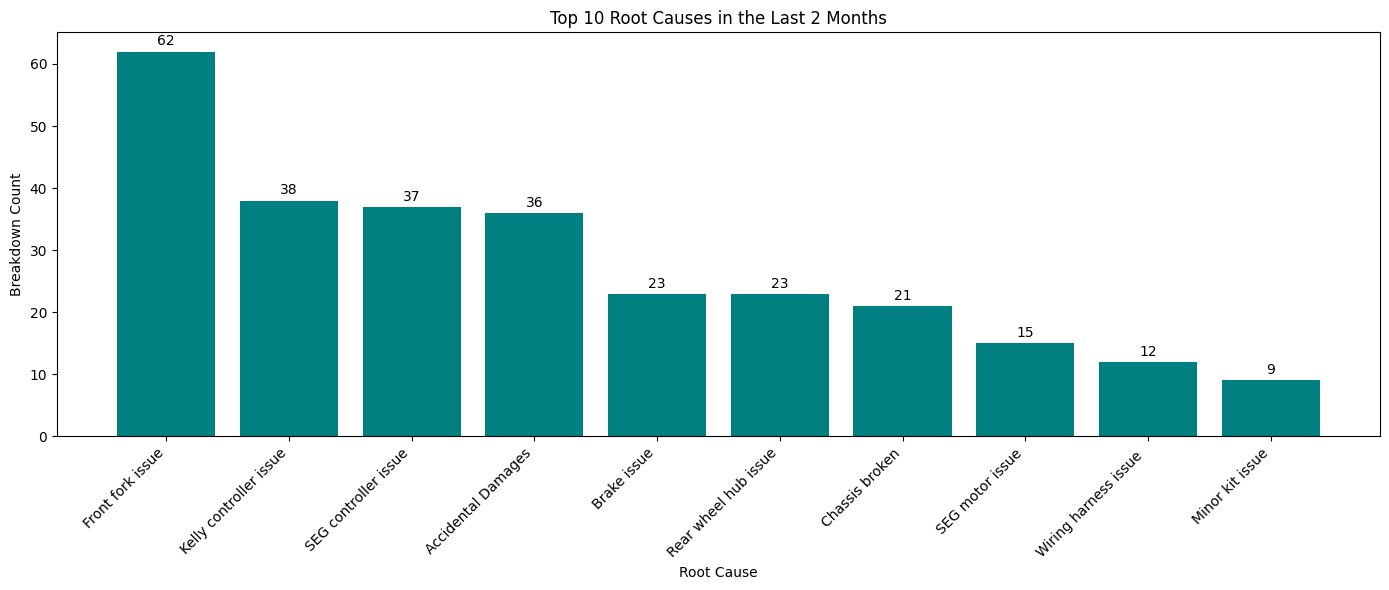

In [ ]:
import matplotlib.pyplot as plt

# Filter data for the last two months based on Incident Date
latest_date = data['Incident Date'].max()
two_months_ago = latest_date - pd.DateOffset(months=2)
last_2_months_data = data[(data['Incident Date'] >= two_months_ago) & (data['Incident Date'] <= latest_date)]

# Group by Root cause and count breakdowns
root_cause_counts = last_2_months_data.groupby('Root cause')['ID'].count().sort_values(ascending=False)

# Create a DataFrame for display
root_cause_df = root_cause_counts.reset_index().rename(columns={'ID': 'Breakdown Count'})
display(root_cause_df)

# Plot the top 10 root causes
top_n = 10
plt.figure(figsize=(14, 6))
bars = plt.bar(root_cause_df['Root cause'][:top_n], root_cause_df['Breakdown Count'][:top_n], color='teal')
plt.xlabel('Root Cause')
plt.ylabel('Breakdown Count')
plt.title('Top 10 Root Causes in the Last 2 Months')
plt.xticks(rotation=45, ha='right')

# Add data labels
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.5, int(yval), ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

In [ ]:
root_cause_df.head()

,Root cause,Breakdown Count
0,Controller issues,130
1,Front fork issue,71
2,Chassis broken,46
3,Wiring harness issue,32
4,Datai Motor issue,23


In [ ]:
# Filter out rows with 'Incident Type' as 'Accident'
non_accident_data = last_2_months_data[last_2_months_data['Incident Type'].str.strip().str.lower() != 'accident']

# Get top 10 root causes by count (excluding accidents)
top_10_non_accident_causes = (
    non_accident_data['Root cause']
    .value_counts()
    .head(10)
    .index
)

# Filter rows for these top 10 root causes
top_10_non_accident_full = non_accident_data[
    non_accident_data['Root cause'].isin(top_10_non_accident_causes)
]

# Display all rows and columns for these top 10 root causes (without accidents)
display(top_10_non_accident_full)

,ID,vin,RTO Registration Number,Vehicle model,FOS,FON,Incident Date,Incident Time,Incident Type,Status,Responsiblity,Root cause,Date of Closure,Time of Closure,Month,Year,Week,Year_Week
0,IR2025072714,MD9B55CWWPC558711,MH04KX8329,S8Ci,Bhiwandi,MMB,2025-07-27,17.38,Mechanical,RESOLVED,3evi,Chassis broken,NaT,NaN,7,2025,30,2025-30
1,IR2025072713,MD9B30CWWNA558276,MH04KX8332,S8Ci,Bhiwandi,MMB,2025-07-27,17.38,Mechanical,CREATED,3evi,Chassis broken,2025-07-29,22.05,7,2025,30,2025-30
2,IR2025072712,MD9B30CWWNF558574,MH04KX5732,Rhino,Bhiwandi,MMB,2025-07-27,17.38,Mechanical,RESOLVED,3evi,Front fork issue,NaT,NaN,7,2025,30,2025-30
3,IR2025072711,MD9B55CWWPD558810,MH04KX8326,S8Ci,Bhiwandi,MMB,2025-07-27,17.38,Mechanical,RESOLVED,3evi,Rear wheel hub issue,NaT,NaN,7,2025,30,2025-30
5,IR202507279,MD9B55CWWPF558909,KA53AB2672,S8Ci,Bhiwandi,MMB,2025-07-27,17.38,Electrical,RESOLVED,3evi,Controller issues,NaT,NaN,7,2025,30,2025-30
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
603,IR202505278,MD9B30CWWNB558320,KA53AA5395,S8Ci,Mahadevapura,BLR,2025-05-27,9.18,Electrical,RESOLVED,3evi,Controller issues,2025-05-29,19.54,5,2025,22,2025-22
604,IR202505277,MD9B30CWWMJ558216,KA53AA4928,S8Ci,Komapally,HYD,2025-05-27,11.35,Electrical,RESOLVED,3evi,Wiring harness issue,2025-05-28,14.24,5,2025,22,2025-22
605,IR202505276,MD9B55CWWRJ559241,KA43A4231,S8Ci,Sahakar Nagar,BLR,2025-05-27,13.34,Electrical,RESOLVED,3evi,Controller issues,2025-05-31,0.18,5,2025,22,2025-22
607,IR202505273,FBJC650365,KA03D1208,e30x,Ghatkopar Electric Fuel,MMB,2025-05-27,12.28,Electrical,RESOLVED,3evi,Wiring harness issue,2025-05-28,23.57,5,2025,22,2025-22


In [ ]:
# Filter out 'Accidental damages' and select top 10 root causes with all columns from last_2_months_data
top_10_root_causes_full = last_2_months_data[
    last_2_months_data['Root cause'] != 'Accidental damages'
].copy()

# Get the top 10 root causes by count
top_10_causes = (
    top_10_root_causes_full['Root cause']
    .value_counts()
    .head(10)
    .index
)

# Filter rows for these top 10 root causes
top_10_root_causes_full = top_10_root_causes_full[
    top_10_root_causes_full['Root cause'].isin(top_10_causes)
]

# Convert to CSV format (as string)
csv_data_full = top_10_root_causes_full.to_csv(index=False)
print(csv_data_full)

ID,vin,RTO Registration Number,Vehicle model,FOS,FON,Incident Date,Incident Time,Incident Type,Status,Responsiblity,Root cause,Date of Closure,Time of Closure,Month,Year,Week,Year_Week
IR2025072714,MD9B55CWWPC558711,MH04KX8329,S8Ci,Bhiwandi,MMB,2025-07-27,17.38,Mechanical,RESOLVED,3evi,Chassis broken,,,7,2025,30,2025-30
IR2025072713,MD9B30CWWNA558276,MH04KX8332,S8Ci,Bhiwandi,MMB,2025-07-27,17.38,Mechanical,CREATED,3evi,Chassis broken,2025-07-29,22.05,7,2025,30,2025-30
IR2025072712,MD9B30CWWNF558574,MH04KX5732,Rhino,Bhiwandi,MMB,2025-07-27,17.38,Mechanical,RESOLVED,3evi,Front fork issue,,,7,2025,30,2025-30
IR2025072711,MD9B55CWWPD558810,MH04KX8326,S8Ci,Bhiwandi,MMB,2025-07-27,17.38,Mechanical,RESOLVED,3evi,Rear wheel hub issue,,,7,2025,30,2025-30
IR202507279,MD9B55CWWPF558909,KA53AB2672,S8Ci,Bhiwandi,MMB,2025-07-27,17.38,Electrical,RESOLVED,3evi, Controller issues,,,7,2025,30,2025-30
IR202507278,MBX0000ZBMK144296,KA01AA3098,e30x,Bhiwandi,MMB,2025-07-27,17.38,Mechanical,RESOLVED,3evi,Car

In [ ]:
# Filter out 'Accidental damages' and select top 10 root causes
top_10_root_causes = root_cause_df[root_cause_df['Root cause'] != 'Accidental damages'].head(10)

# Convert to CSV format (as string)
csv_data = top_10_root_causes.to_csv(index=False)
print(csv_data)

Root cause,Breakdown Count
 Controller issues,130
Front fork issue,71
Chassis broken,46
Wiring harness issue,32
Datai Motor issue,23
Rear wheel hub issue,22
Minor kit issue,21
Throttle issue,17
Battery issue,14
Cargo box door lock issue,13



In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3504 entries, 0 to 3503
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   ID                       3504 non-null   object        
 1   vin                      3504 non-null   object        
 2   RTO Registration Number  3504 non-null   object        
 3   Vehicle Model            3504 non-null   object        
 4   FOS                      3504 non-null   object        
 5   FON                      3504 non-null   object        
 6   Incident Date            3504 non-null   datetime64[ns]
 7   Incident Time            3504 non-null   float64       
 8   Incident Type            3504 non-null   object        
 9   Status                   3504 non-null   object        
 10  Responsiblity            3498 non-null   object        
 11  Root cause               3504 non-null   object        
 12  Date of Closure          3334 non-

In [ ]:
#Repeat front fork issues

In [ ]:
filtered=data[(data)]

ValueError: Boolean array expected for the condition, not object

In [ ]:

from IPython.display import display, HTML

# Filter for September and October 2025
filtered = data[(data['Year'] == 2025) & (data['Month'].isin([9, 10]))]

# Group by FON and Status, then count
status_counts = (
    filtered.groupby(['FON', 'Status'])
    .size()
    .reset_index(name='Count')
    .sort_values(['FON', 'Status'])
)

# Display table in Colab
display(HTML("<h3>FON-wise Status Counts (Sept–Oct 2025)</h3>"))
display(status_counts)





,FON,Status,Count
0,FON_001,Closed,1
1,FON_001,Open,1
2,FON_002,Closed,1
3,FON_002,In Progress,1
4,FON_002,Open,1
5,FON_003,Closed,1
6,FON_003,Open,1


In [ ]:
filtered=data[(data['Year']==2025) & (data['Month'].isin([9,10]))]